# Trabajo práctico 1: Optimización

> Notebook canónico y autocontenido del proyecto.

**Equipo:** Alejandro Quesada, Manfred Azofeifa, Jose Adrián Herrera

**Estado:** trabajo en progreso; análisis gráfico inicial implementado.


## Objetivo y protocolo

- TODO: Resumir el objetivo del experimento.
- TODO: Definir criterios de convergencia y métricas.
- TODO: Registrar decisiones que deban mantenerse entre algoritmos.


## Configuración y reproducibilidad

Esta sección debe concentrar imports, semilla, dispositivo, dominio, número de corridas, puntos iniciales compartidos y demás parámetros globales.


In [1]:
# TODO: Agregar imports y definir aquí toda la configuración compartida.
# TODO: Crear una sola vez los puntos iniciales reutilizados por los algoritmos.
import math
import random

import numpy as np
import optuna
import pandas as pd
import torch

import utils

# Constantes a utilizar
DOMAIN_MIN = -10.0
DOMAIN_MAX = 10.0
GRID_POINTS = 401

## Convención de documentación interna

Documentar cada función con bloques compatibles con Doxygen. Ejemplo genérico:

```python
def metodo(entrada):
    """!
    @brief Descripción breve.
    @param entrada Descripción del parámetro.
    @return Descripción del resultado.
    """
```


### Funciones auxiliares

Las funciones reutilizables de análisis, visualización y presentación de tablas se mantienen en \`utils.py\` para conservar el flujo principal del notebook enfocado en los experimentos.

## Análisis de las funciones

Las tres funciones se evalúan sobre una malla compartida en $[-10, 10]^2$ y se muestran mediante curvas de nivel y superficies 3D.

### 1) $f_0(x, y)$  - Función Cuadrática
$$
f_0(x, y) = x^2 + y^2
$$


In [2]:
def f0(x: torch.Tensor):
    """!
    @brief Evalúa la función cuadrática f0 sobre tensores de PyTorch.
    @param x Coordenadas x1 y x2.
    @return Valores de f0(x, y).
    """    
    return x[0] ** 2 + x[1] ** 2



x = torch.linspace(DOMAIN_MIN, DOMAIN_MAX, GRID_POINTS)
y = torch.linspace(DOMAIN_MIN, DOMAIN_MAX, GRID_POINTS)

X, Y = torch.meshgrid(x, y, indexing='ij')
Z0 = f0(torch.stack((X, Y)))
Z0.shape

torch.Size([401, 401])

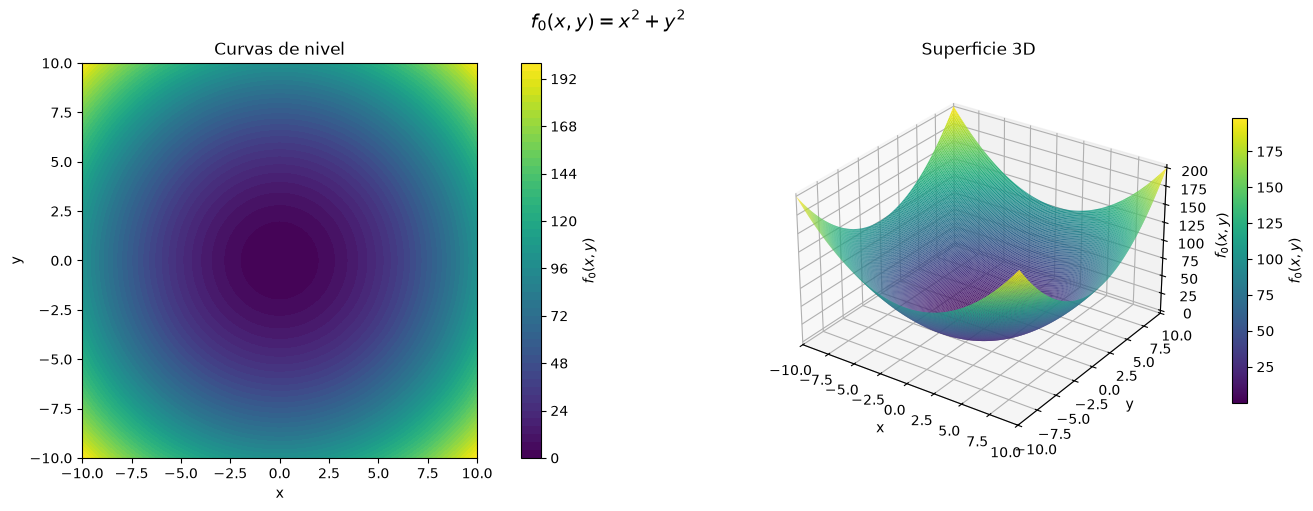

In [3]:
utils.plot_function_2d_3d(
    X,
    Y,
    Z0,
    title=r"$f_0(x, y) = x^2 + y^2$",
    z_label=r"$f_0(x, y)$",
)

### $f_1(x, y)$ - función de Ackley

$$
f_1(x,y) = -20\exp\left[-0.2\sqrt{0.5(x^2+y^2)}\right] - \exp\left[0.5(\cos(2\pi x)+\cos(2\pi y))\right] + e + 20
$$


In [4]:
def f1(x: torch.Tensor):
    """!
    @brief Evalúa la función de Ackley f1 sobre tensores de PyTorch.
    @param x puntos del tensor en ambas dimensiones
    @return Valores de f1(x, y).
    """
    exp1 = -0.2 * torch.sqrt(0.5 * f0(x))
    mitad1 = -20 * torch.exp(exp1)

    exp2 = 0.5 * (torch.cos(2.0 * torch.pi * x[0]) + torch.cos(2.0 * torch.pi * x[1]))
    mitad2 = -torch.exp(exp2)
    return mitad1 + mitad2 + torch.e + 20.0

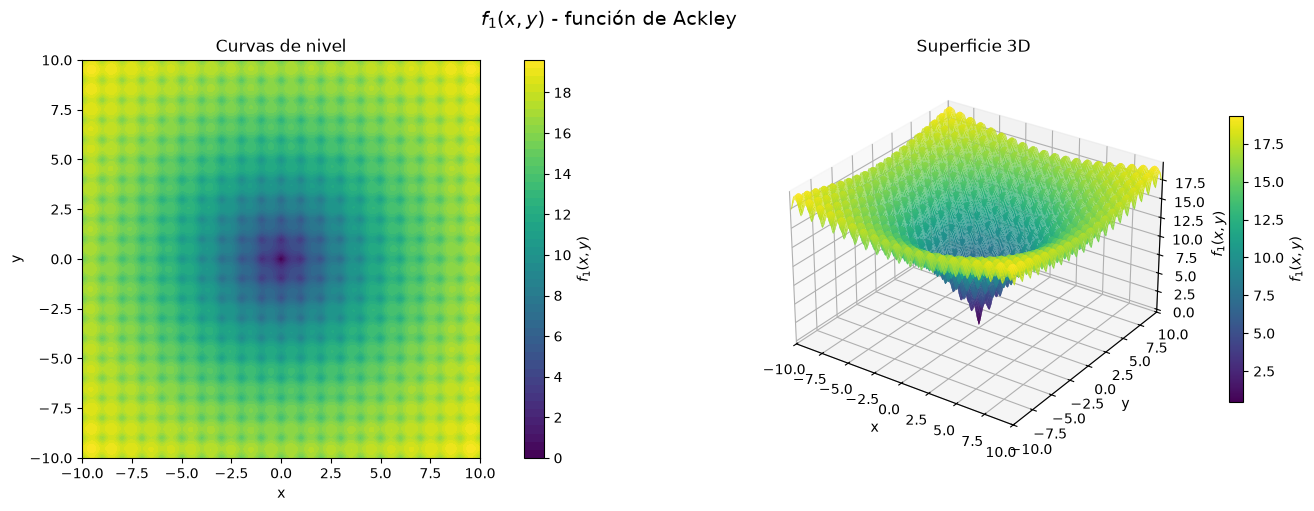

In [5]:
Z1 = f1(torch.stack((X, Y)))
utils.plot_function_2d_3d(
    X,
    Y,
    Z1,
    title=r"$f_1(x, y)$ - función de Ackley",
    z_label=r"$f_1(x, y)$",
)

### $f_2(x, y)$ - función de Himmelblau

$$f_2(x,y) = (x^2+y-11)^2 + (x+y^2-7)^2$$


In [6]:
def f2(x: torch.Tensor):
    """!
    @brief Evalúa la función de Himmelblau f2 sobre tensores de PyTorch.
    @param x Coordenadas de la función en un torch.Tensor
    @return Valores de f2(x, y).
    """
    return (x[0] ** 2 + x[1] - 11.0) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2

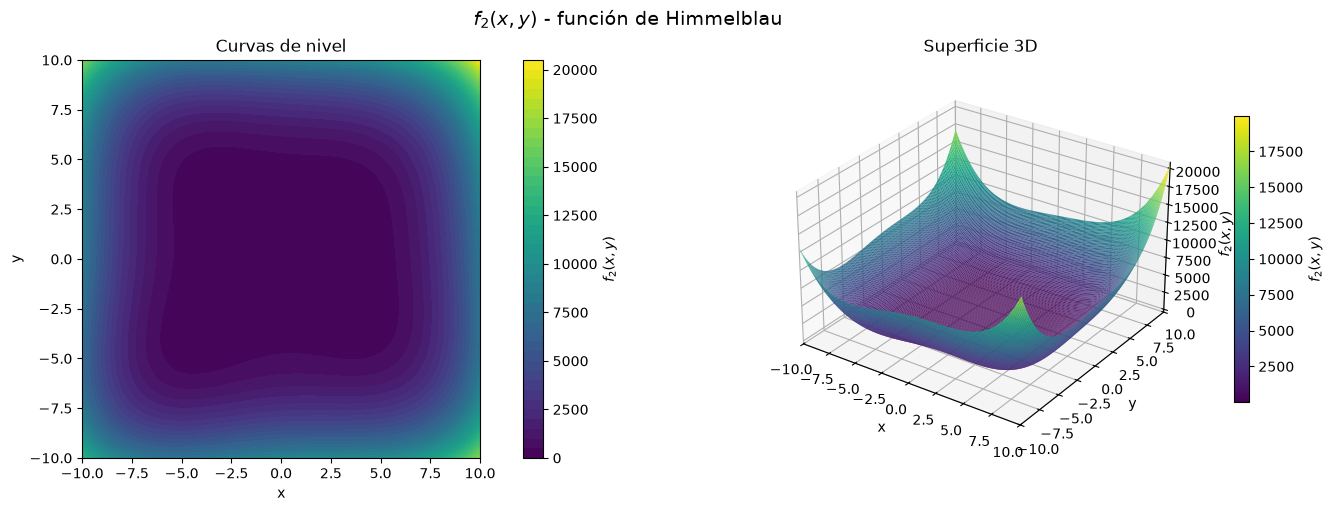

In [7]:
Z2 = f2(torch.stack((X, Y)))
utils.plot_function_2d_3d(
    X,
    Y,
    Z2,
    title=r"$f_2(x, y)$ - función de Himmelblau",
    z_label=r"$f_2(x, y)$",
)

---
### ¿Son convexas o no convexas?

- $f_0$ es convexa.
- $f_1$ y $f_2$ son no convexas.

---
### Encontrando mínimos y puntos silla con PyTorch

Primero usamos la malla que ya construimos. `torch.min(Z)` devuelve el menor **valor muestreado**, mientras que `torch.argmin(Z)` permite recuperar sus coordenadas. Como la malla contiene una cantidad finita de puntos, este resultado es una aproximación cuya precisión depende de `GRID_POINTS`.

Después usamos Autograd para buscar puntos donde el gradiente sea cercano a cero. Esos puntos se clasifican como mínimos locales o puntos silla con una prueba sencilla sobre la Hessiana $2\times2$.

In [8]:
# Valores mínimos aproximados observados en la malla
min0 = torch.min(Z0)
min1 = torch.min(Z1)
min2 = torch.min(Z2)

puntos_minimos_malla = {
    "f0": utils.coordenadas_minimo_malla(X, Y, Z0),
    "f1": utils.coordenadas_minimo_malla(X, Y, Z1),
    "f2": utils.coordenadas_minimo_malla(X, Y, Z2),
}

resumen_malla = pd.DataFrame(
    [
        {
            "función": "f0",
            "x": puntos_minimos_malla["f0"][0].item(),
            "y": puntos_minimos_malla["f0"][1].item(),
            "valor mínimo en la malla": min0.item(),
        },
        {
            "función": "f1",
            "x": puntos_minimos_malla["f1"][0].item(),
            "y": puntos_minimos_malla["f1"][1].item(),
            "valor mínimo en la malla": min1.item(),
        },
        {
            "función": "f2",
            "x": puntos_minimos_malla["f2"][0].item(),
            "y": puntos_minimos_malla["f2"][1].item(),
            "valor mínimo en la malla": min2.item(),
        },
    ]
)
resumen_malla["valor mínimo en la malla"] = resumen_malla[
    "valor mínimo en la malla"
].map(lambda value: f"{value:.3e}")
utils.mostrar_tabla(
    resumen_malla.round({"x": 6, "y": 6}),
    "Mínimos aproximados observados en la malla",
)

,función,x,y,valor mínimo en la malla
0,f0,-0.000000,-0.000000,4.441e-14
1,f1,-0.000000,-0.000000,0.000e+00
2,f2,3.000000,2.000000,2.274e-13


#### 1. Gradiente y Hessiana con Autograd

Un punto crítico suave cumple $\nabla f(x,y)\approx(0,0)$. Para calcularlo, el tensor `punto` usa `requires_grad=True`. Luego `torch.autograd.grad` obtiene primero las dos componentes del gradiente y después las dos filas de la Hessiana.

#### 2. Refinamiento con el método de Newton

Las curvas de nivel nos dan puntos iniciales aproximados. Desde cada uno aplicamos

$$H(p)\,\text{paso}=\nabla f(p), \qquad p_{nuevo}=p-\text{paso}.$$

`torch.linalg.solve` resuelve el pequeño sistema lineal sin calcular explícitamente $H^{-1}$. Newton puede converger a un mínimo, un máximo o un punto silla; la clasificación se realiza en el paso siguiente.

> Newton depende del punto inicial y puede fallar si la Hessiana no es invertible. En ese caso se debe probar otro inicio tomado de la gráfica.

#### 3. Clasificación con la Hessiana

Para una Hessiana de dos variables calculamos $D=\det(H)$:

- $D<0$: existen direcciones con curvaturas de signos opuestos, por lo que es un **punto silla**;
- $D>0$ y $f_{xx}>0$: hay curvatura positiva en ambas direcciones, por lo que es un **mínimo local**;
- $D>0$ y $f_{xx}<0$: es un máximo local;
- $D\approx0$: esta prueba no permite concluir.

También guardamos $\lVert\nabla f\rVert$ para comprobar que Newton realmente llegó cerca de un punto estacionario.

#### 4. Resultados para $f_0$

Como $f_0=x^2+y^2\geq0$, el punto con valor cero es global. Además, su Hessiana es positiva y constante, de manera que no existen puntos silla.

In [9]:
punto_f0 = utils.encontrar_punto_estacionario(f0, inicio=(1.0, 1.0))
resultado_f0 = utils.clasificar_punto(f0, punto_f0)
resultado_f0["tipo"] = "mínimo global"

resultados_f0 = [resultado_f0]
minimos_globales_f0 = [resultado_f0["punto"]]
minimos_locales_f0 = []
puntos_silla_f0 = []

utils.mostrar_tabla(
    utils.resultados_a_tabla(resultados_f0),
    "Puntos críticos identificados para f0",
)

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo global,0.000000,0.000000,0.000000,0.00e+00,4.000000


#### 5. Resultados para $f_1$ (Ackley)

El mínimo de la malla está en el origen y vale cero. También sabemos que $f_1\geq0$ porque el término radial no puede ser menor que $-20$ y el término periódico no puede ser menor que $-e$; por tanto, $(0,0)$ es el mínimo global.

En el origen la norma euclídea produce una punta no suave, así que no aplicamos allí la prueba Hessiana. Para practicar el procedimiento mostramos mínimos locales y puntos silla **representativos cerca del origen**. Ackley repite este patrón y tiene muchos más en todo $[-10,10]^2$.

In [10]:
inicios_minimos_f1 = [
    (-1.0, 0.0),
    (1.0, 0.0),
    (0.0, -1.0),
    (0.0, 1.0),
    (-1.0, -1.0),
    (-1.0, 1.0),
    (1.0, -1.0),
    (1.0, 1.0),
]
inicios_silla_f1 = [
    (-0.7, 0.0),
    (0.7, 0.0),
    (0.0, -0.7),
    (0.0, 0.7),
]

resultados_f1 = []
for inicio in inicios_minimos_f1 + inicios_silla_f1:
    punto = utils.encontrar_punto_estacionario(f1, inicio)
    resultados_f1.append(utils.clasificar_punto(f1, punto))

minimos_globales_f1 = [
    torch.tensor((0.0, 0.0), dtype=torch.float64)
]
minimos_locales_f1 = [
    resultado["punto"]
    for resultado in resultados_f1
    if resultado["tipo"] == "mínimo local"
]
puntos_silla_f1 = [
    resultado["punto"]
    for resultado in resultados_f1
    if resultado["tipo"] == "punto silla"
]

utils.mostrar_tabla(
    utils.resultados_a_tabla(resultados_f1),
    "Puntos críticos identificados para f1",
)

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo local,-0.952167,0.000000,2.579928,6.74e-09,2613.708044
1,mínimo local,0.952167,0.000000,2.579928,6.74e-09,2613.708044
2,mínimo local,0.000000,-0.952167,2.579928,6.74e-09,2613.708044
3,mínimo local,0.000000,0.952167,2.579928,6.74e-09,2613.708044
4,mínimo local,-0.968478,-0.968478,3.574452,5.13e-10,2623.098354
5,mínimo local,-0.968478,0.968478,3.574452,5.13e-10,2623.098354
6,mínimo local,0.968478,-0.968478,3.574452,5.13e-10,2623.098354
7,mínimo local,0.968478,0.968478,3.574452,5.13e-10,2623.098354
8,punto silla,-0.625781,0.000000,3.252469,8.11e-11,-601.475321
9,punto silla,0.625781,0.000000,3.252469,8.11e-11,-601.475321


#### 5.1. Mínimos locales de Ackley en todo el dominio

Los ocho puntos anteriores permiten estudiar la clasificación cerca del origen, pero no son todos los mínimos locales. El término periódico de Ackley produce un pozo cerca de cada punto entero no nulo de $[-10,10]^2$; el término radial desplaza cada mínimo ligeramente hacia el origen.

Usamos cada punto entero no nulo como inicio de Newton, conservamos únicamente los puntos clasificados como mínimos locales dentro del dominio y eliminamos duplicados. Este es un procedimiento numérico, no una demostración analítica de que la lista sea exhaustiva.

In [11]:
minimos_locales_f1_dominio = utils.encontrar_minimos_ackley_en_dominio(
    f1,
    DOMAIN_MIN,
    DOMAIN_MAX,
)
assert len(minimos_locales_f1_dominio) == 440
print(
    f"Se identificaron {len(minimos_locales_f1_dominio)} mínimos locales "
    "de Ackley dentro del dominio."
)

Se identificaron 440 mínimos locales de Ackley dentro del dominio.


#### 6. Resultados para $f_2$ (Himmelblau)

`torch.argmin` mostró un solo mínimo de la malla porque devuelve un único índice. Usamos como inicios puntos aproximados observados en los otros valles de las curvas de nivel. Los cuatro mínimos encontrados hacen que los dos cuadrados de $f_2$ sean prácticamente cero; como una suma de cuadrados nunca es negativa, los cuatro son mínimos globales.

In [12]:
inicios_minimos_f2 = [
    (3.0, 2.0),
    (-3.0, 3.0),
    (-4.0, -3.0),
    (4.0, -2.0),
]
inicios_silla_f2 = [
    (3.0, 0.0),
    (0.0, 3.0),
    (-3.0, 0.0),
    (0.0, -2.0),
]

resultados_f2 = []
for inicio in inicios_minimos_f2 + inicios_silla_f2:
    punto = utils.encontrar_punto_estacionario(f2, inicio)
    resultado = utils.clasificar_punto(f2, punto)
    if resultado["tipo"] == "mínimo local" and abs(resultado["valor"]) < 1e-6:
        resultado["tipo"] = "mínimo global"
    resultados_f2.append(resultado)

minimos_globales_f2 = [
    resultado["punto"]
    for resultado in resultados_f2
    if resultado["tipo"] == "mínimo global"
]
minimos_locales_f2 = []
puntos_silla_f2 = [
    resultado["punto"]
    for resultado in resultados_f2
    if resultado["tipo"] == "punto silla"
]

utils.mostrar_tabla(
    utils.resultados_a_tabla(resultados_f2),
    "Puntos críticos identificados para f2",
)

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo global,3.000000,2.000000,0.000000,0.00e+00,2116.000000
1,mínimo global,-2.805118,3.131313,0.000000,1.13e-14,5222.896681
2,mínimo global,-3.779310,-3.283186,0.000000,6.00e-11,9460.563454
3,mínimo global,3.584428,-1.848127,0.000000,1.88e-11,3024.539865
4,punto silla,3.385154,0.073852,13.311926,3.14e-10,-1378.856668
5,punto silla,0.086678,2.884255,67.719150,5.85e-09,-2394.091252
6,punto silla,-3.073026,-0.081353,104.015163,3.03e-10,-2872.165968
7,punto silla,-0.127961,-1.953715,178.337239,2.34e-10,-1026.580624


#### 7. Verificación numérica

Las siguientes comprobaciones confirman que los puntos suaves tienen gradiente cercano a cero, que el signo del determinante concuerda con su clasificación y que los mínimos globales encontrados tienen valor cercano a cero.

In [13]:
resultados_suaves = resultados_f0 + resultados_f1 + resultados_f2

assert len(minimos_locales_f1) == 8
assert len(minimos_locales_f1_dominio) == 440
assert len(puntos_silla_f1) == 4
assert len(puntos_silla_f2) == 4
assert all(
    resultado["norma_gradiente"] < 1e-6
    for resultado in resultados_suaves
)
assert all(
    resultado["det_hessiana"] < 0
    for resultado in resultados_suaves
    if resultado["tipo"] == "punto silla"
)
assert all(
    resultado["det_hessiana"] > 0
    for resultado in resultados_suaves
    if "mínimo" in resultado["tipo"]
)
assert abs(f0(minimos_globales_f0[0]).item()) < 1e-8
assert abs(f1(minimos_globales_f1[0]).item()) < 1e-8
assert len(minimos_globales_f2) == 4
assert all(
    abs(f2(punto).item()) < 1e-8
    for punto in minimos_globales_f2
)

print("Verificación completada: gradientes, Hessianas y valores globales correctos.")

Verificación completada: gradientes, Hessianas y valores globales correctos.


#### 8. Gráficas de los puntos encontrados

La función `plot_critical_points` se encuentra en `utils.py`. Las estrellas doradas son mínimos globales, los círculos celestes mínimos locales y las equis rojas puntos silla. Estas gráficas usan una vista cercana para distinguir los marcadores; las gráficas anteriores conservan el dominio completo $[-10,10]^2$.

El color usa $\log(1+f)$ únicamente para que los valles sean visibles; las coordenadas y los valores de los puntos no se modifican.

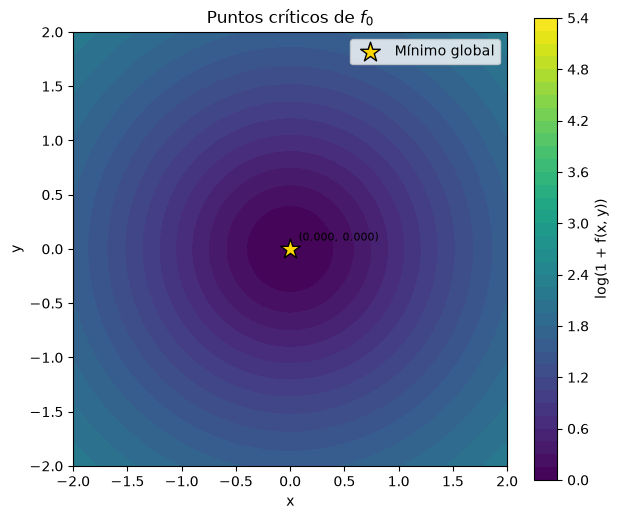

In [14]:
utils.plot_critical_points(
    X,
    Y,
    Z0,
    minimos_globales_f0,
    minimos_locales_f0,
    puntos_silla_f0,
    title=r"Puntos críticos de $f_0$",
    view_limits=(-2.0, 2.0),
)

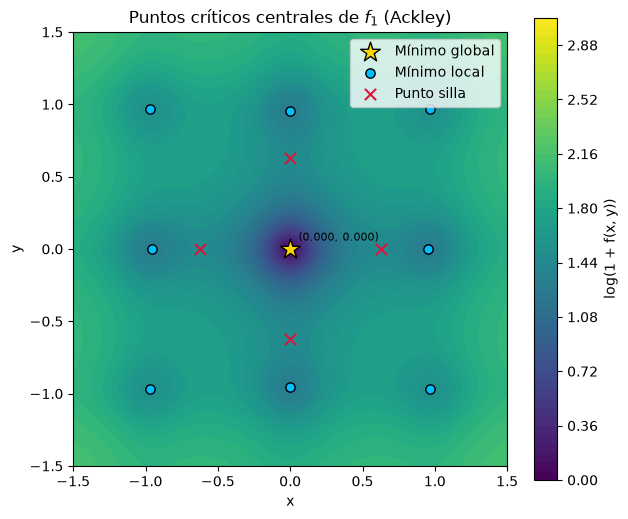

In [15]:
utils.plot_critical_points(
    X,
    Y,
    Z1,
    minimos_globales_f1,
    minimos_locales_f1,
    puntos_silla_f1,
    title=r"Puntos críticos centrales de $f_1$ (Ackley)",
    view_limits=(-1.5, 1.5),
)

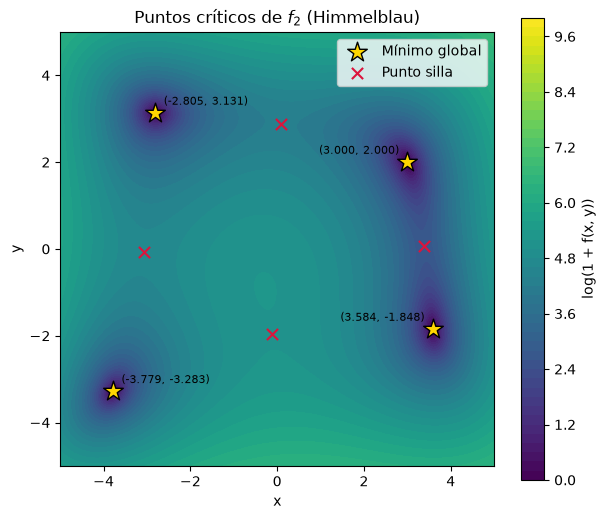

In [16]:
utils.plot_critical_points(
    X,
    Y,
    Z2,
    minimos_globales_f2,
    minimos_locales_f2,
    puntos_silla_f2,
    title=r"Puntos críticos de $f_2$ (Himmelblau)",
    view_limits=(-5.0, 5.0),
)

## Descenso del gradiente

### 1. Cálculo del gradiente con Autograd

Al crear un tensor con `requires_grad=True`, PyTorch registra las operaciones usadas para calcular la función. Después, `torch.autograd.grad(valor, punto)` obtiene el gradiente de **la función que se recibió como parámetro**.

La función de Ackley no es diferenciable exactamente en el origen por el término con la raíz cuadrada. Por eso la comprobación se realiza en el punto $(1, 1)$.

In [17]:
def run_gd(alpha, t, func, punto_inicial):
    """!
    @brief Ejecuta t pasos de descenso del gradiente usando Autograd.
    @param alpha Tasa de aprendizaje.
    @param t Cantidad de actualizaciones.
    @param func Función objetivo que recibe un tensor bidimensional.
    @param punto_inicial Coordenadas iniciales dentro del dominio de trabajo.
    @return Historiales apilados de puntos y valores, incluido el estado final.
    """
    xt = torch.tensor(
        punto_inicial,
        dtype=torch.float64,
        requires_grad=True,
    )
    f_hist = []
    x_hist = []

    for _ in range(t):
        f_xt, gradiente = utils.valor_y_gradiente(func, xt)
        if not torch.isfinite(f_xt) or not torch.isfinite(gradiente).all():
            raise ValueError(
                "GD divergió: pruebe una tasa de aprendizaje más pequeña."
            )

        f_hist.append(f_xt.detach().clone())
        x_hist.append(xt.detach().clone())
        xt = (xt - alpha * gradiente).detach().requires_grad_(True)

    x_hist.append(xt.detach().clone())
    f_hist.append(func(xt).detach().clone())
    return torch.stack(x_hist), torch.stack(f_hist)

### 2. Aplicación a $f_0$

El punto inicial se selecciona uniformemente al azar dentro de $[-10,10]^2$.

In [18]:
p0_inicial = utils.generar_punto_inicial(DOMAIN_MIN, DOMAIN_MAX)
X0_hist, f0_hist = run_gd(
    alpha=0.1,
    t=25,
    func=f0,
    punto_inicial=p0_inicial,
)
print(f"Punto inicial de f0: {p0_inicial}")

Punto inicial de f0: (5.747660028278549, -8.564634227641687)


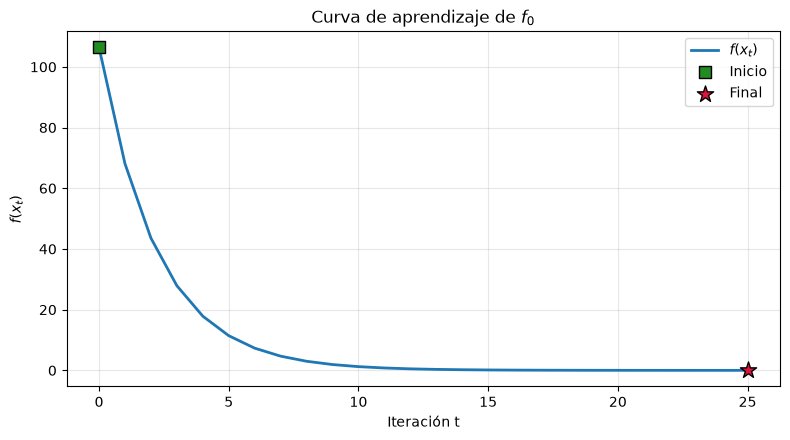

In [19]:
utils.plot_learning_curve(
    f0_hist,
    title=r"Curva de aprendizaje de $f_0$",
);

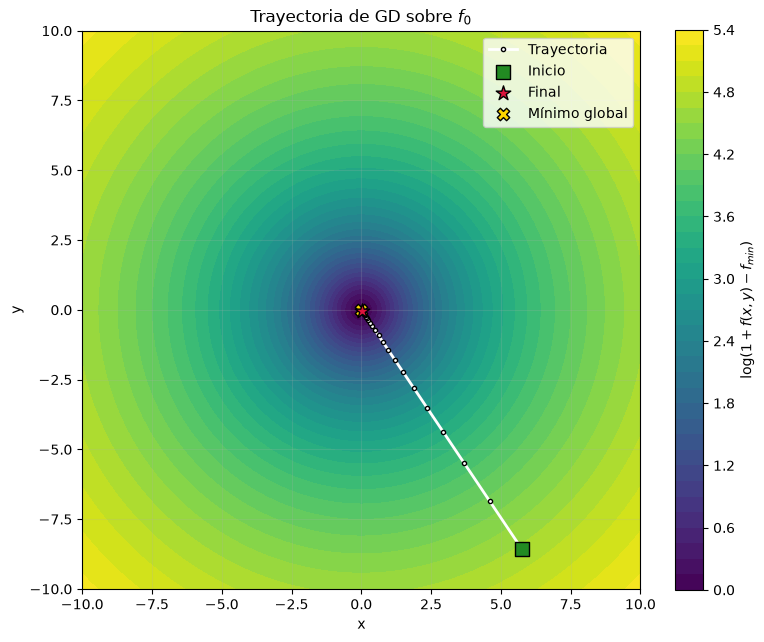

In [20]:
utils.plot_func_hist(
    x,
    y,
    f0,
    X0_hist,
    title=r"Trayectoria de GD sobre $f_0$",
    minima=minimos_globales_f0);

### 3. Aplicación a $f_1$

Ackley tiene 440 mínimos locales suaves en el dominio, además del mínimo global en el origen. Un inicio aleatorio puede conducir a cualquiera de sus cuencas de atracción.

In [21]:
p1_inicial = utils.generar_punto_inicial(DOMAIN_MIN, DOMAIN_MAX)
X1_hist, f1_hist = run_gd(
    alpha=0.01,
    t=25,
    func=f1,
    punto_inicial=p1_inicial,
)
print(f"Punto inicial de f1: {p1_inicial}")

Punto inicial de f1: (-0.024399039889996033, -1.7699446388544526)


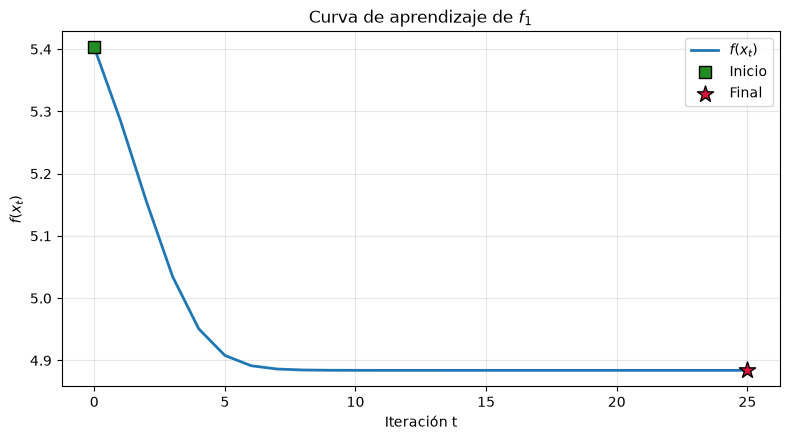

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Curva de aprendizaje de $f_1$'}, xlabel='Iteración t', ylabel='$f(x_t)$'>)

In [22]:
utils.plot_learning_curve(f1_hist, title=r"Curva de aprendizaje de $f_1$")

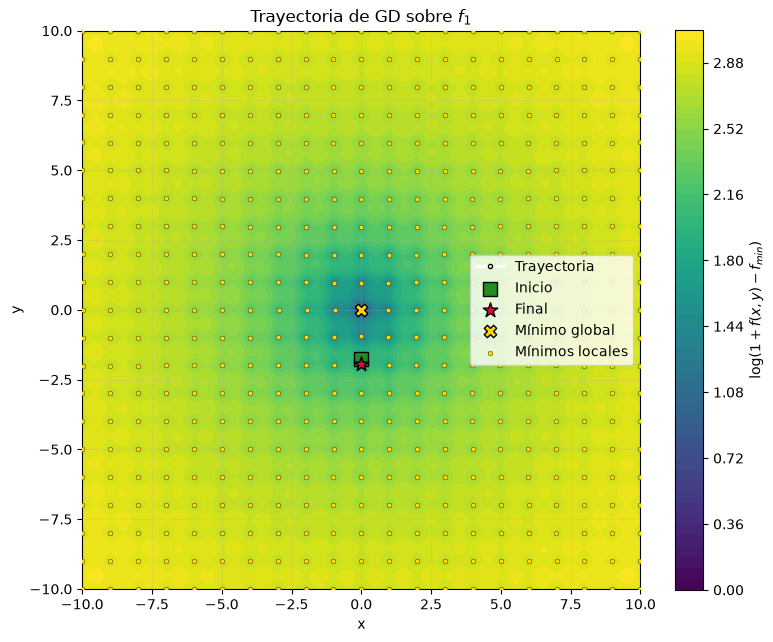

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de GD sobre $f_1$'}, xlabel='x', ylabel='y'>)

In [23]:
utils.plot_func_hist(x, y, f1, X1_hist,
    title=r"Trayectoria de GD sobre $f_1$",
    minima=minimos_globales_f1,
    local_minima=minimos_locales_f1_dominio)

### 4. Aplicación a $f_2$

El inicio sigue siendo aleatorio en $[-10,10]^2$, pero aquí se necesita un paso menor. $f_2$ es una función de grado cuatro, por lo que su gradiente crece aproximadamente como el cubo de las coordenadas lejos de los mínimos.

Por ejemplo, en $(10,10)$ el gradiente es aproximadamente $(4166,4318)$. Con $\alpha=0.01$, un solo paso lleva a $(-31.66,-33.18)$; fuera del dominio el siguiente gradiente es todavía mayor y la sucesión puede desbordarse. Esto no es un problema del inicio aleatorio, sino de usar un paso demasiado grande para las zonas más empinadas.

Usamos $\alpha=0.002$ y más iteraciones. Así se conserva el descenso del gradiente básico y el requisito de iniciar al azar.

In [24]:
p2_inicial = utils.generar_punto_inicial(DOMAIN_MIN, DOMAIN_MAX)
X2_hist, f2_hist = run_gd(
    alpha=0.002,
    t=25,
    func=f2,
    punto_inicial=p2_inicial,
)
print(f"Punto inicial de f2: {p2_inicial}")

Punto inicial de f2: (-8.23925907169675, 1.6319544382211788)


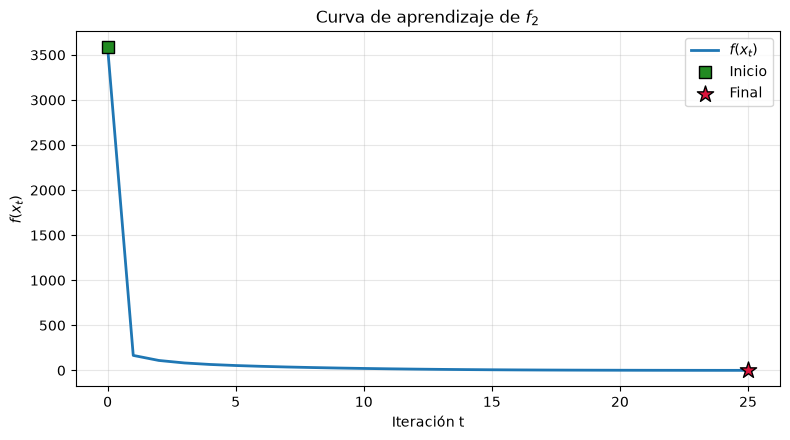

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Curva de aprendizaje de $f_2$'}, xlabel='Iteración t', ylabel='$f(x_t)$'>)

In [25]:
utils.plot_learning_curve(
    f2_hist,
    title=r"Curva de aprendizaje de $f_2$")

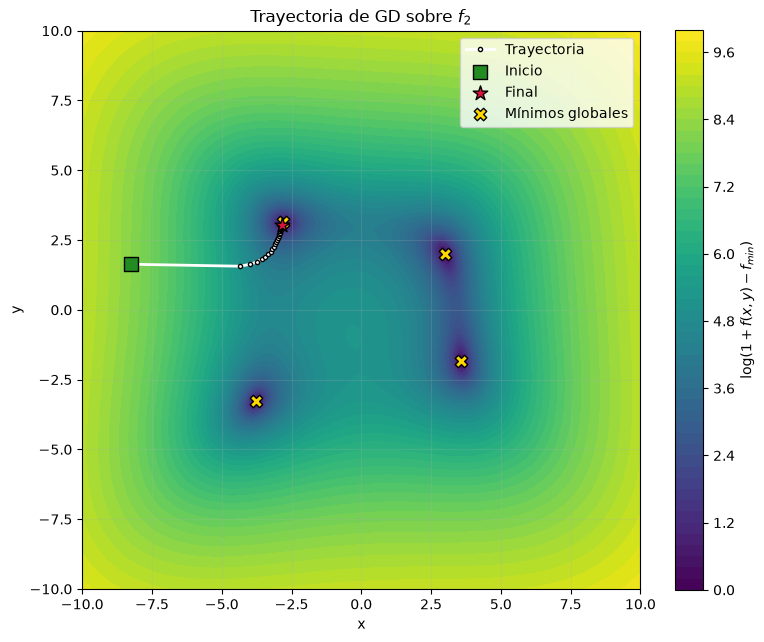

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de GD sobre $f_2$'}, xlabel='x', ylabel='y'>)

In [26]:
utils.plot_func_hist(x, y, f2, X2_hist,
    title=r"Trayectoria de GD sobre $f_2$",
    minima=minimos_globales_f2)

---
## RMSProp

RMSProp conserva un promedio móvil, por coordenada, de los gradientes al cuadrado. Así toma del método de momentum la idea de dar más peso a la información reciente, pero la usa para adaptar la escala de cada componente del paso:

$$
\mathbf{s}_t = \gamma \mathbf{s}_{t-1} + (1-\gamma)\mathbf{g}_t^2,
\qquad
\mathbf{x}_{t+1} = \mathbf{x}_t -
\frac{\alpha}{\sqrt{\mathbf{s}_t + \epsilon}}\odot\mathbf{g}_t.
$$

Se usa $\mathbf{s}_0=\mathbf{0}$, $\gamma=0.9$ y $\epsilon=10^{-6}$. Cada experimento ejecuta 25 actualizaciones y reutiliza el punto inicial de descenso del gradiente correspondiente, de modo que la comparación parte de la misma solución. La implementación sigue la formulación de [Dive into Deep Learning: RMSProp](https://d2l.ai/chapter_optimization/rmsprop.html).

In [27]:
def run_rmsprop(alpha, gamma, epsilon, t, func, punto_inicial):
    """!
    @brief Ejecuta t pasos de RMSProp usando gradientes calculados con Autograd.
    @param alpha Tasa de aprendizaje.
    @param gamma Peso del promedio móvil de gradientes al cuadrado.
    @param epsilon Constante positiva que estabiliza la división.
    @param t Cantidad de actualizaciones.
    @param func Función objetivo que recibe un tensor bidimensional.
    @param punto_inicial Coordenadas iniciales dentro del dominio de trabajo.
    @return Historiales apilados de puntos y valores, incluido el estado final.
    """
    xt = torch.tensor(
        punto_inicial,
        dtype=torch.float64,
        requires_grad=True,
    )
    promedio_cuadrados = torch.zeros_like(xt)
    f_hist = []
    x_hist = []

    for _ in range(t):
        f_xt, gradiente = utils.valor_y_gradiente(func, xt)
        if not torch.isfinite(f_xt) or not torch.isfinite(gradiente).all():
            raise ValueError("RMSProp divergió: revise la tasa de aprendizaje.")

        f_hist.append(f_xt.detach().clone())
        x_hist.append(xt.detach().clone())

        promedio_cuadrados = (
            gamma * promedio_cuadrados
            + (1.0 - gamma) * gradiente.square()
        )
        if not torch.isfinite(promedio_cuadrados).all():
            raise ValueError(
                "RMSProp divergió: el promedio de gradientes no es finito."
            )

        paso = alpha * gradiente / torch.sqrt(promedio_cuadrados + epsilon)
        xt = (xt - paso).detach().requires_grad_(True)

    x_hist.append(xt.detach().clone())
    f_hist.append(func(xt).detach().clone())
    return torch.stack(x_hist), torch.stack(f_hist)

### Aplicación de RMSProp a $f_0$

Para la función cuadrática se usa $\alpha=0.5$.

f0: 106.388555 -> 0.003624


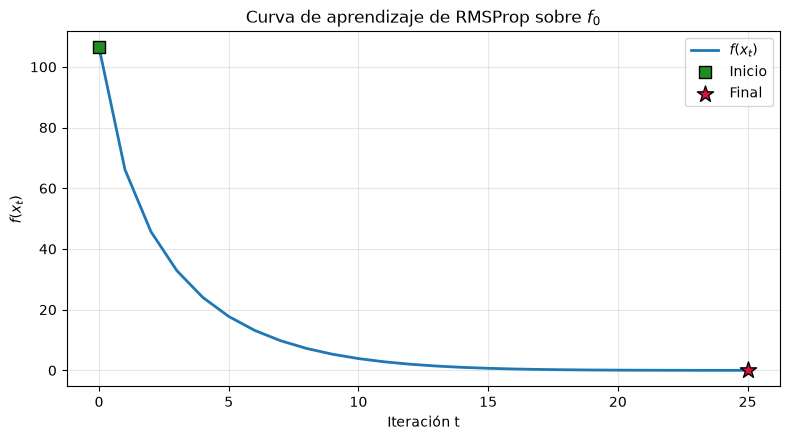

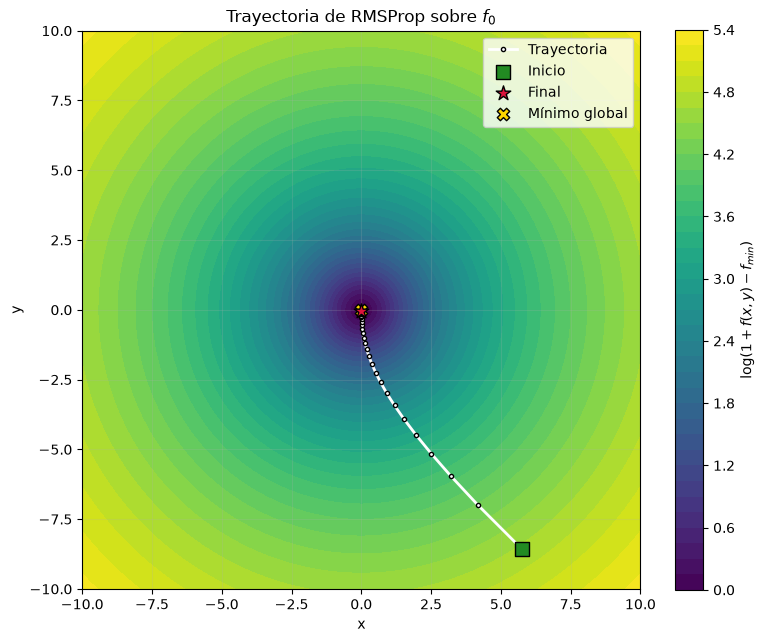

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de RMSProp sobre $f_0$'}, xlabel='x', ylabel='y'>)

In [28]:
X0_rms_hist, f0_rms_hist = run_rmsprop(
    alpha=0.5,
    gamma=0.9,
    epsilon=1e-6,
    t=25,
    func=f0,
    punto_inicial=p0_inicial,
)

print(
    f"f0: {f0_rms_hist[0].item():.6f} -> "
    f"{f0_rms_hist[-1].item():.6f}"
)

utils.plot_learning_curve(
    f0_rms_hist,
    title=r"Curva de aprendizaje de RMSProp sobre $f_0$",
)

utils.plot_func_hist(
    x,
    y,
    f0,
    X0_rms_hist,
    title=r"Trayectoria de RMSProp sobre $f_0$",
    minima=minimos_globales_f0,
)

### Aplicación de RMSProp a $f_1$

Ackley puede conducir a un mínimo local distinto del origen. Se usa un paso conservador $\alpha=0.05$.

f1: 5.402650 -> 4.910180


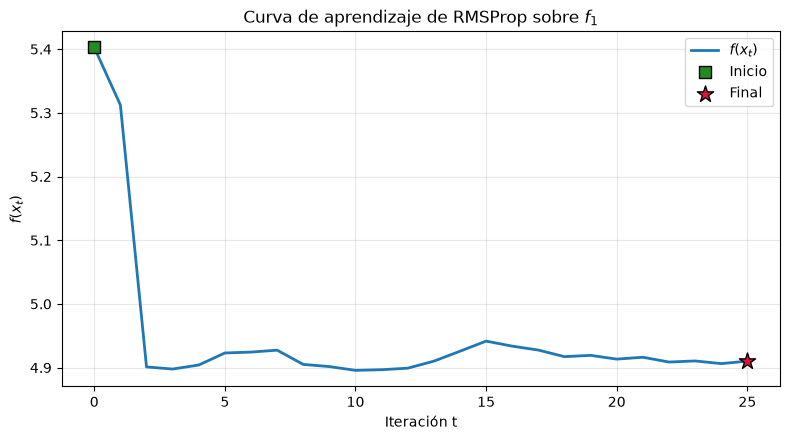

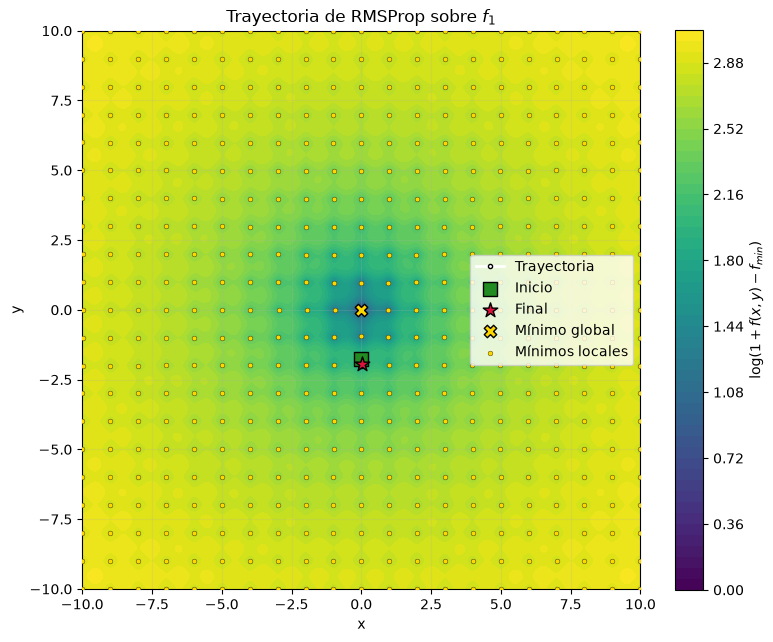

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de RMSProp sobre $f_1$'}, xlabel='x', ylabel='y'>)

In [29]:
X1_rms_hist, f1_rms_hist = run_rmsprop(
    alpha=0.05,
    gamma=0.9,
    epsilon=1e-6,
    t=25,
    func=f1,
    punto_inicial=p1_inicial,
)
print(
    f"f1: {f1_rms_hist[0].item():.6f} -> "
    f"{f1_rms_hist[-1].item():.6f}"
)

utils.plot_learning_curve(
    f1_rms_hist,
    title=r"Curva de aprendizaje de RMSProp sobre $f_1$",
)

utils.plot_func_hist(
    x,
    y,
    f1,
    X1_rms_hist,
    title=r"Trayectoria de RMSProp sobre $f_1$",
    minima=minimos_globales_f1,
    local_minima=minimos_locales_f1_dominio,
)

### Aplicación de RMSProp a $f_2$

Para Himmelblau se usa $\alpha=0.4$; el escalado por coordenada mantiene controlados los pasos en las regiones empinadas.

f2: 3582.434974 -> 0.344453


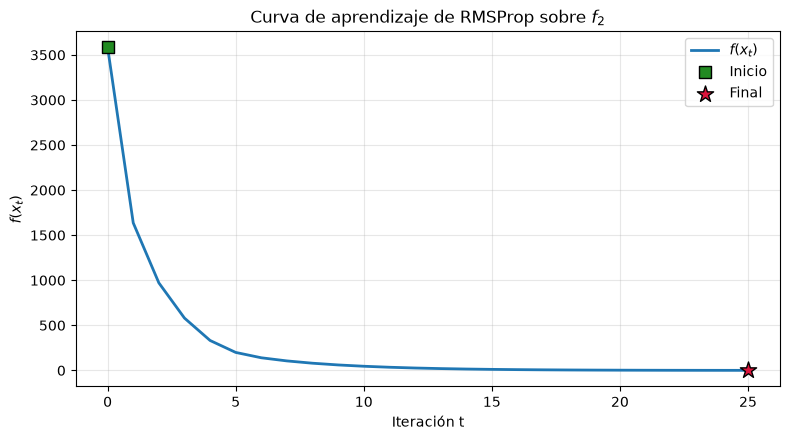

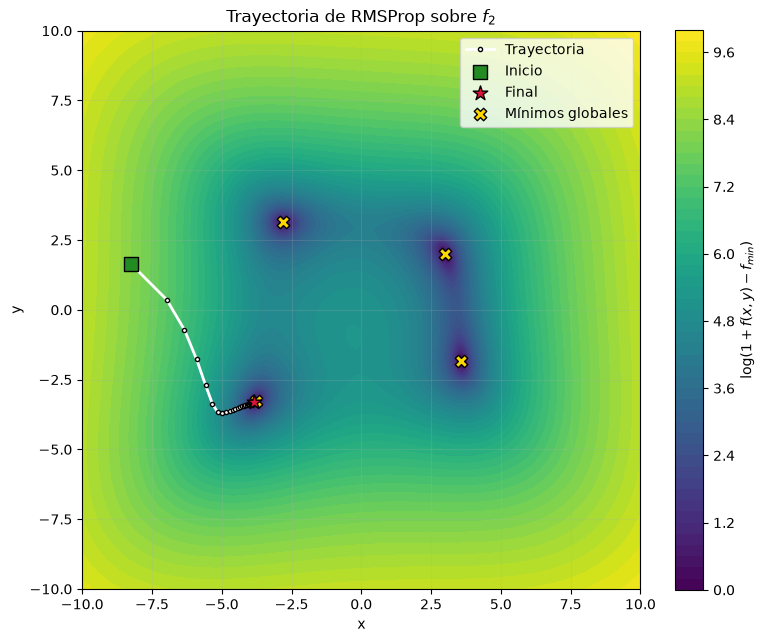

(<Figure size 800x650 with 2 Axes>,
 <Axes: title={'center': 'Trayectoria de RMSProp sobre $f_2$'}, xlabel='x', ylabel='y'>)

In [30]:
X2_rms_hist, f2_rms_hist = run_rmsprop(
    alpha=0.4,
    gamma=0.9,
    epsilon=1e-6,
    t=25,
    func=f2,
    punto_inicial=p2_inicial,
)
print(
    f"f2: {f2_rms_hist[0].item():.6f} -> "
    f"{f2_rms_hist[-1].item():.6f}"
)

utils.plot_learning_curve(
    f2_rms_hist,
    title=r"Curva de aprendizaje de RMSProp sobre $f_2$",
)

utils.plot_func_hist(
    x,
    y,
    f2,
    X2_rms_hist,
    title=r"Trayectoria de RMSProp sobre $f_2$",
    minima=minimos_globales_f2,
)

---
## Enjambre de Partículas _(Particle Swarm Optimization)_


In [31]:
#TODO: Implementar PSO

---
## Calibración de GD y RMSProp con Optuna

La calibración usa el mismo presupuesto de 25 actualizaciones y los mismos seis puntos iniciales para todos los estudios. La cantidad de iteraciones no es un hiperparámetro:

- GD ajusta solamente alpha.
- RMSProp ajusta alpha y gamma; epsilon permanece fijo en $10^{-6}$.

Optuna minimiza directamente el promedio de los seis valores finales de la función, sin penalizaciones adicionales. Se considera convergencia cuando la brecha respecto al valor mínimo conocido satisface $|f(x_t)-f^*|\leq 10^{-3}$. Como $f^*=0$ para $f_0$, $f_1$ y $f_2$, se registra el primer valor con $|f(x_t)|\leq 10^{-3}$ como métrica diagnóstica. Esta tolerancia no altera ni redondea el objetivo y todas las corridas conservan el presupuesto fijo.

In [32]:
ITERACIONES_OPTUNA = 25
TOLERANCIA_CONVERGENCIA = 1e-3
EPSILON_RMSPROP = 1e-6
N_TRIALS_OPTUNA = 25

generador_optuna = random.Random(42)
puntos_validacion_optuna = [
    (
        generador_optuna.uniform(DOMAIN_MIN, DOMAIN_MAX),
        generador_optuna.uniform(DOMAIN_MIN, DOMAIN_MAX),
    )
    for _ in range(6)
]

configuraciones_optuna = {
    "f0": {
        "funcion": f0,
        "valor_minimo": 0.0,
        "gd_alpha_min": 0.01,
        "gd_alpha_max": 0.49,
        "rms_alpha_min": 0.01,
        "rms_alpha_max": 1.0,
        "gamma_min": 0.5,
        "gamma_max": 0.999,
    },
    "f1": {
        "funcion": f1,
        "valor_minimo": 0.0,
        "gd_alpha_min": 0.001,
        "gd_alpha_max": 0.5,
        "rms_alpha_min": 0.001,
        "rms_alpha_max": 0.5,
        "gamma_min": 0.5,
        "gamma_max": 0.999,
    },
    "f2": {
        "funcion": f2,
        "valor_minimo": 0.0,
        "gd_alpha_min": 0.0002,
        "gd_alpha_max": 0.04,
        "rms_alpha_min": 0.01,
        "rms_alpha_max": 2.0,
        "gamma_min": 0.5,
        "gamma_max": 0.999,
    },
}

utils.mostrar_tabla(
    pd.DataFrame(
        puntos_validacion_optuna,
        columns=["x inicial", "y inicial"],
    ).round(4),
    "Puntos iniciales compartidos para el ajuste con Optuna",
)

utils.mostrar_tabla(
    pd.DataFrame(
        [
            {
                "función": nombre,
                "iteraciones fijas": ITERACIONES_OPTUNA,
                "GD alpha": (
                    config["gd_alpha_min"],
                    config["gd_alpha_max"],
                ),
                "RMSProp alpha": (
                    config["rms_alpha_min"],
                    config["rms_alpha_max"],
                ),
                "RMSProp gamma": (
                    config["gamma_min"],
                    config["gamma_max"],
                ),
            }
            for nombre, config in configuraciones_optuna.items()
        ]
    ),
    "Espacios de búsqueda e iteraciones fijas de Optuna",
)

,x inicial,y inicial
0,2.788500,-9.499800
1,-4.499400,-5.535800
2,4.729400,3.534000
3,7.843600,-8.261200
4,-1.561600,-9.404100
5,-5.627200,0.107100


,función,iteraciones fijas,GD alpha,RMSProp alpha,RMSProp gamma
0,f0,25,"(0.01, 0.49)","(0.01, 1.0)","(0.5, 0.999)"
1,f1,25,"(0.001, 0.5)","(0.001, 0.5)","(0.5, 0.999)"
2,f2,25,"(0.0002, 0.04)","(0.01, 2.0)","(0.5, 0.999)"


### 1. Función objetivo de los estudios

Cada ensayo ejecuta exactamente 25 actualizaciones desde cada uno de los seis puntos iniciales compartidos. La función objetivo que Optuna minimiza es el **promedio directo de los valores finales de la función**; no se agregan penalizaciones por convergencia, cantidad de iteraciones ni distancia a la tolerancia.

Si una configuración diverge o produce un valor no finito, el ensayo se poda mediante el mecanismo nativo de Optuna. La tolerancia $|f(x_t)-f^*|\leq 10^{-3}$ se conserva únicamente para informar cuántas corridas convergieron y en qué primera iteración lo hicieron; no modifica el valor objetivo.

### 2. Ejecución de los estudios

Cada función genera un estudio para GD y otro para RMSProp. Los seis estudios usan 25 ensayos, semillas reproducibles, los mismos seis puntos de ajuste y exactamente 25 actualizaciones por corrida.

In [33]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
estudios_optuna = {
    "GD": {},
    "RMSProp": {},
}

for indice_algoritmo, algoritmo in enumerate(estudios_optuna):
    for indice_funcion, (nombre, configuracion) in enumerate(
        configuraciones_optuna.items()
    ):
        estudio = optuna.create_study(
            direction="minimize",
            study_name=f"{algoritmo}_{nombre}",
            sampler=optuna.samplers.TPESampler(
                seed=42 + 10 * indice_algoritmo + indice_funcion
            ),
        )
        estudio.optimize(
            utils.crear_objetivo_optuna(
                algoritmo,
                configuracion,
                puntos_validacion_optuna,
                iteraciones=ITERACIONES_OPTUNA,
                tolerancia=TOLERANCIA_CONVERGENCIA,
                epsilon_rmsprop=EPSILON_RMSPROP,
                ejecutar_gd=run_gd,
                ejecutar_rmsprop=run_rmsprop,
            ),
            n_trials=N_TRIALS_OPTUNA,
            show_progress_bar=False,
        )
        estudios_optuna[algoritmo][nombre] = estudio
        print(
            f"Estudio {algoritmo} de {nombre}: "
            f"{len(estudio.trials)} ensayos."
        )

Estudio GD de f0: 25 ensayos.
Estudio GD de f1: 25 ensayos.
Estudio GD de f2: 25 ensayos.
Estudio RMSProp de f0: 25 ensayos.
Estudio RMSProp de f1: 25 ensayos.
Estudio RMSProp de f2: 25 ensayos.


### 3. Gráficas del proceso de búsqueda

El historial muestra el promedio final obtenido por cada ensayo y el mejor valor acumulado. GD presenta únicamente el efecto de alpha; RMSProp presenta los efectos de alpha y gamma. La cantidad de iteraciones no aparece porque permanece fija.

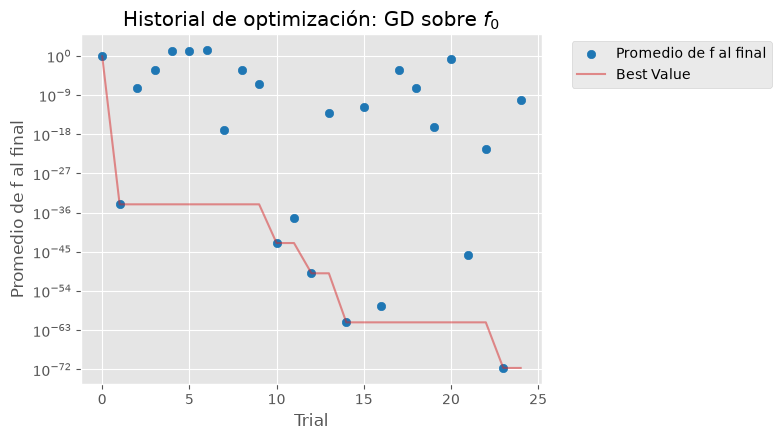

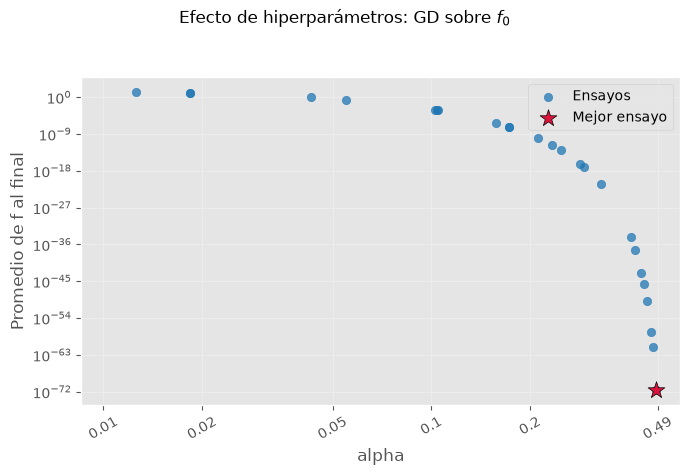

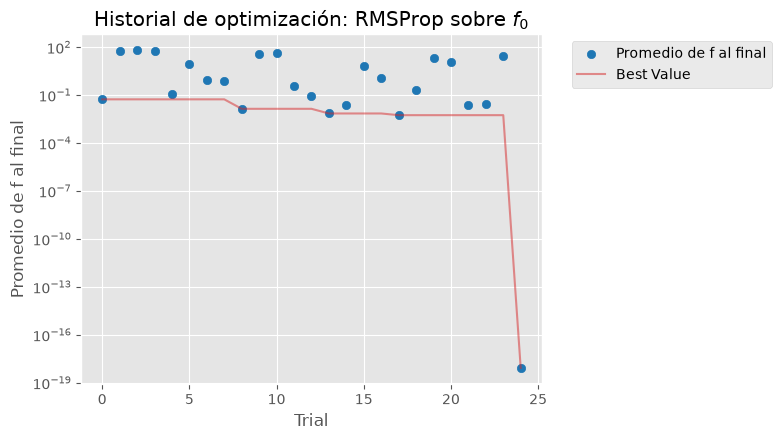

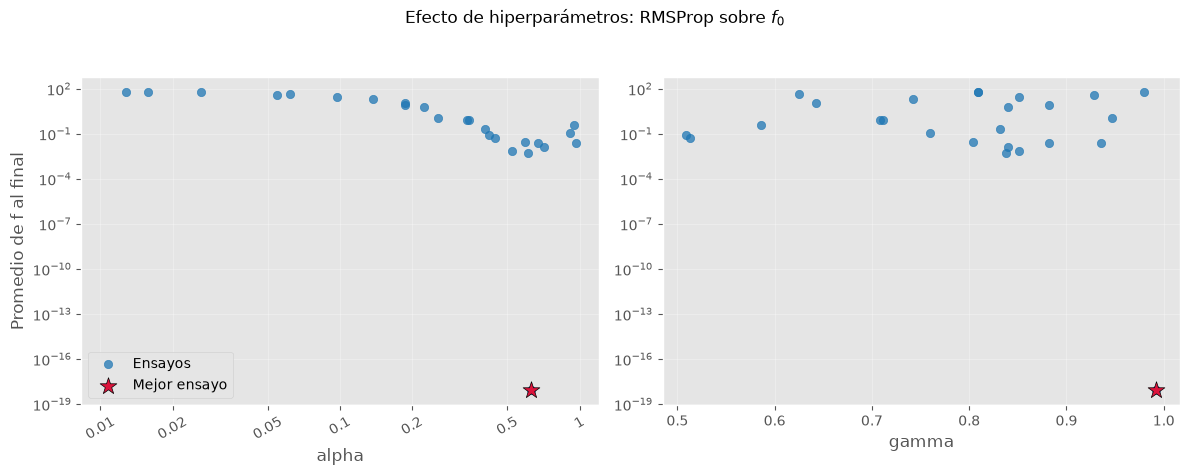

In [34]:
utils.plot_estudio_optuna(
    estudios_optuna["GD"]["f0"],
    r"$f_0$",
    "GD",
    ["alpha"],
)
utils.plot_estudio_optuna(
    estudios_optuna["RMSProp"]["f0"],
    r"$f_0$",
    "RMSProp",
    ["alpha", "gamma"],
)

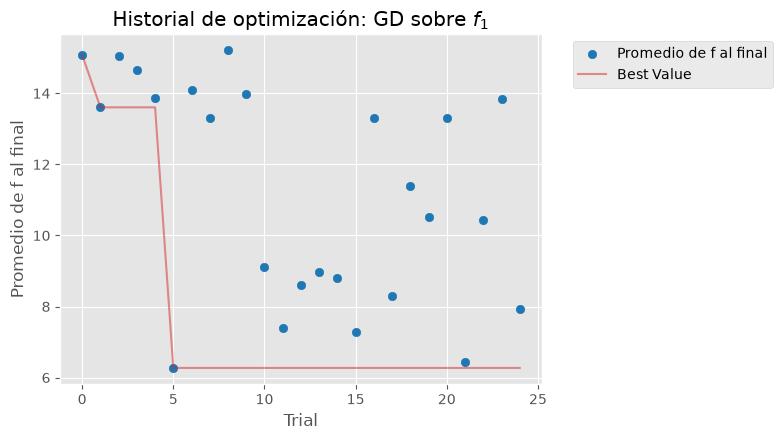

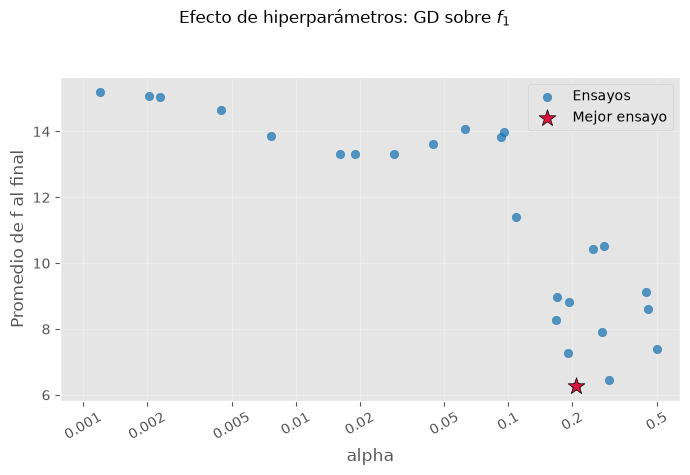

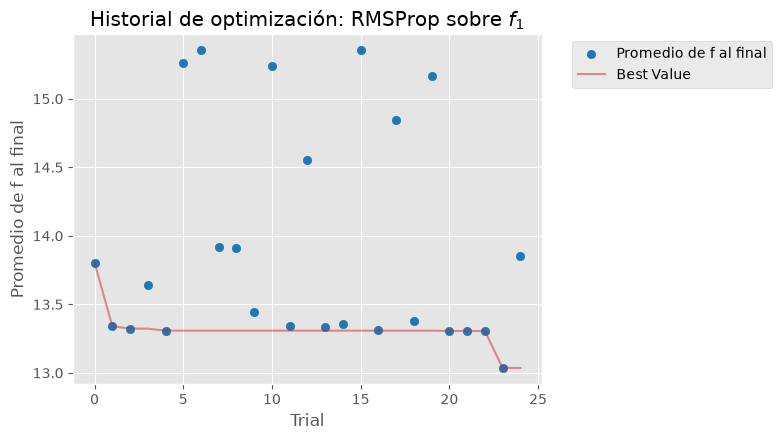

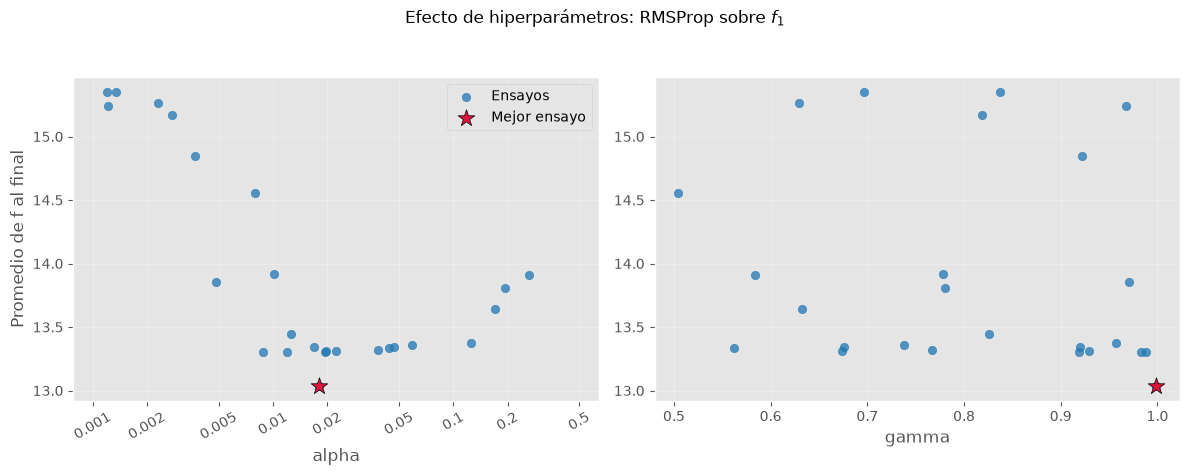

In [35]:
utils.plot_estudio_optuna(
    estudios_optuna["GD"]["f1"],
    r"$f_1$",
    "GD",
    ["alpha"],
)
utils.plot_estudio_optuna(
    estudios_optuna["RMSProp"]["f1"],
    r"$f_1$",
    "RMSProp",
    ["alpha", "gamma"],
)

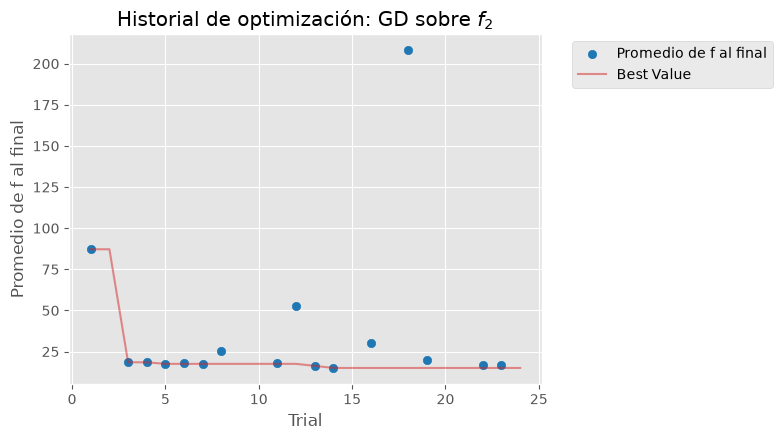

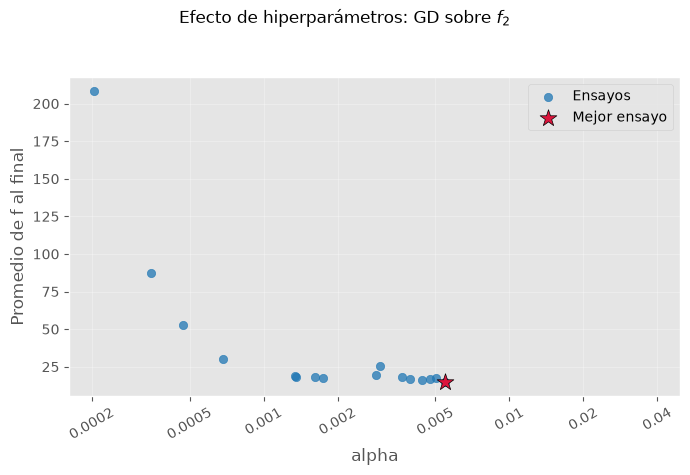

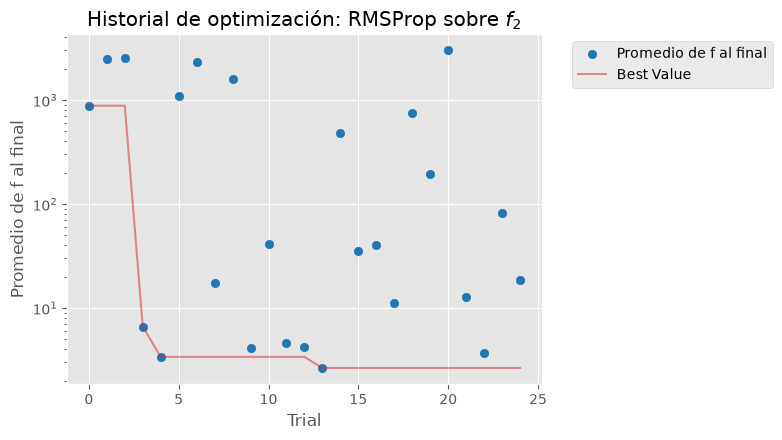

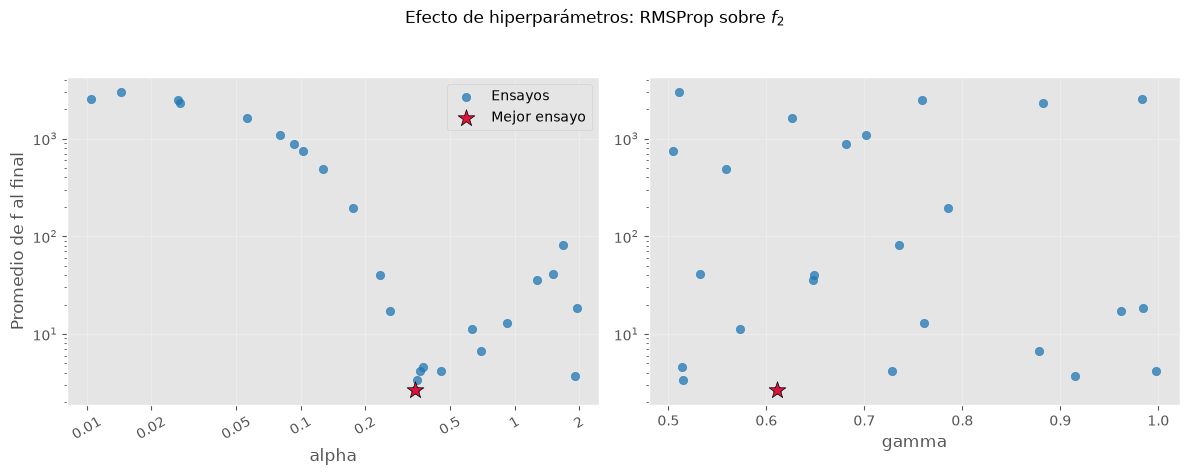

In [36]:
utils.plot_estudio_optuna(
    estudios_optuna["GD"]["f2"],
    r"$f_2$",
    "GD",
    ["alpha"],
)
utils.plot_estudio_optuna(
    estudios_optuna["RMSProp"]["f2"],
    r"$f_2$",
    "RMSProp",
    ["alpha", "gamma"],
)

### 4. Mejores hiperparámetros encontrados

La tabla muestra el promedio final que Optuna minimiza directamente y, por separado, las métricas diagnósticas de convergencia. Las corridas convergentes se reportan en el primer punto que satisface la tolerancia; las no convergentes conservan el valor de la iteración 25. El promedio de iteraciones usa solamente corridas convergentes.

In [37]:
filas_resumen_optuna = []

for algoritmo, estudios_por_funcion in estudios_optuna.items():
    for nombre, estudio in estudios_por_funcion.items():
        mejor = estudio.best_trial
        filas_resumen_optuna.append(
            {
                "algoritmo": algoritmo,
                "función": nombre,
                "mejor alpha": mejor.params["alpha"],
                "mejor gamma": mejor.params.get("gamma", np.nan),
                "iteraciones fijas": ITERACIONES_OPTUNA,
                "convergencias ajuste": (
                    f'{mejor.user_attrs["corridas_convergentes"]}/'
                    f'{len(puntos_validacion_optuna)}'
                ),
                "iteraciones promedio": mejor.user_attrs[
                    "iteraciones_promedio_convergencia"
                ],
                "promedio f reportado": mejor.user_attrs[
                    "promedio_valor_reportado"
                ],
                "promedio f final (objetivo Optuna)": mejor.value,
            }
        )

resumen_optuna = pd.DataFrame(filas_resumen_optuna)

utils.mostrar_tabla(
    resumen_optuna,
    "Mejores hiperparámetros encontrados con Optuna",
    formatos={
        "mejor alpha": "{:.6g}",
        "mejor gamma": "{:.6f}",
        "iteraciones promedio": "{:.2f}",
        "promedio f reportado": "{:.6f}",
        "promedio f final (objetivo Optuna)": "{:.6f}",
    },
)

,algoritmo,función,mejor alpha,mejor gamma,iteraciones fijas,convergencias ajuste,iteraciones promedio,promedio f reportado,promedio f final (objetivo Optuna)
0,GD,f0,0.483072,—,25,6/6,2.00,0.000096,0.000000
1,GD,f1,0.208347,—,25,0/6,—,6.271275,6.271275
2,GD,f2,0.005492,—,25,2/6,16.00,15.046626,15.046441
3,RMSProp,f0,0.629157,0.992523,25,6/6,5.00,0.000429,0.000000
4,RMSProp,f1,0.0180058,0.998647,25,0/6,—,13.035986,13.035986
5,RMSProp,f2,0.341559,0.611311,25,2/6,11.50,1.449988,2.656585


## Pruebas unitarias

Mantener aquí al menos dos pruebas documentadas por cada método. Las pruebas forman parte del notebook autocontenido.


In [38]:
def probar_actualizacion_rmsprop():
    """!
    @brief Verifica una actualización de RMSProp contra la ecuación explícita.
    @return None. Falla mediante una aserción si la actualización no coincide.
    """
    alpha = 0.1
    gamma = 0.9
    epsilon = 1e-6
    punto_inicial = (1.0, -2.0)
    punto = torch.tensor(punto_inicial, dtype=torch.float64)

    x_hist, f_hist = run_rmsprop(
        alpha=alpha,
        gamma=gamma,
        epsilon=epsilon,
        t=1,
        func=f0,
        punto_inicial=punto_inicial,
    )

    gradiente_esperado = 2.0 * punto
    promedio_esperado = (
        (1.0 - gamma) * gradiente_esperado.square()
    )
    punto_esperado = punto - (
        alpha
        * gradiente_esperado
        / torch.sqrt(promedio_esperado + epsilon)
    )

    torch.testing.assert_close(x_hist[1], punto_esperado)
    torch.testing.assert_close(f_hist[1], f0(punto_esperado))


def probar_historiales_rmsprop():
    """!
    @brief Verifica forma, finitud y progreso en las tres funciones objetivo.
    @return None. Falla mediante una aserción si algún historial es inválido.
    """
    casos = (
        ("f0", f0, (4.0, -3.0), 0.5),
        ("f1", f1, (2.5, -1.5), 0.05),
        ("f2", f2, (6.0, 6.0), 0.4),
    )

    for nombre, funcion, punto, alpha in casos:
        x_hist, f_hist = run_rmsprop(
            alpha=alpha,
            gamma=0.9,
            epsilon=1e-6,
            t=25,
            func=funcion,
            punto_inicial=punto,
        )

        assert x_hist.shape == (26, 2), nombre
        assert f_hist.shape == (26,), nombre
        assert torch.isfinite(x_hist).all(), nombre
        assert torch.isfinite(f_hist).all(), nombre
        torch.testing.assert_close(
            x_hist[0],
            torch.tensor(punto, dtype=torch.float64),
        )
        assert f_hist[-1] < f_hist[0], nombre


def probar_criterio_convergencia():
    """!
    @brief Verifica que se reporte el primer valor dentro de la tolerancia.
    @return None. Falla si se usa un valor posterior a la primera convergencia.
    """
    valores = torch.tensor(
        [1.0, 5e-4, 1e-12],
        dtype=torch.float64,
    )
    resultado = utils.evaluar_convergencia(
        valores,
        valor_minimo=0.0,
        tolerancia=1e-3,
    )

    assert resultado["convergio"]
    assert resultado["iteraciones"] == 1
    assert resultado["indice_reporte"] == 1
    assert resultado["valor_reportado"] == valores[1].item()


def probar_espacios_optuna():
    """!
    @brief Verifica los parámetros ajustables y el presupuesto fijo de Optuna.
    @return None. Falla si Optuna vuelve a ajustar la cantidad de iteraciones.
    """
    assert ITERACIONES_OPTUNA == 25

    for estudio in estudios_optuna["GD"].values():
        for ensayo in estudio.trials:
            assert set(ensayo.params) == {"alpha"}

    for estudio in estudios_optuna["RMSProp"].values():
        for ensayo in estudio.trials:
            assert set(ensayo.params) == {"alpha", "gamma"}


def probar_objetivo_optuna_directo():
    """!
    @brief Verifica que Optuna reciba el promedio final sin penalizaciones.
    @return None. Falla si el valor del ensayo difiere de la métrica cruda.
    """
    for estudios_por_funcion in estudios_optuna.values():
        for estudio in estudios_por_funcion.values():
            for ensayo in estudio.trials:
                if ensayo.state == optuna.trial.TrialState.COMPLETE:
                    assert math.isclose(
                        ensayo.value,
                        ensayo.user_attrs["promedio_valor_final"],
                        rel_tol=1e-12,
                        abs_tol=1e-12,
                    )


probar_actualizacion_rmsprop()
probar_historiales_rmsprop()
probar_criterio_convergencia()
probar_espacios_optuna()
probar_objetivo_optuna_directo()
print(
    "Pruebas de RMSProp, convergencia, espacios y objetivo directo "
    "de Optuna finalizadas correctamente."
)

# TODO: Agregar las pruebas unitarias de los demás métodos.

Pruebas de RMSProp, convergencia, espacios y objetivo directo de Optuna finalizadas correctamente.


## Evaluación con los mejores hiperparámetros

Se generan diez puntos nuevos con una semilla distinta de la usada por Optuna. Los mismos puntos se reutilizan para GD y RMSProp en las tres funciones.

Cada corrida ejecuta 50 actualizaciones. Se reporta la primera iteración que satisface $|f(x_t)-f^*|\leq 10^{-3}$; si no converge, se reporta el valor después de la actualización 50. El promedio de iteraciones se calcula solamente sobre las corridas convergentes y se acompaña con la cantidad de convergencias sobre diez.

In [39]:
ITERACIONES_EVALUACION = 50
CANTIDAD_CORRIDAS_EVALUACION = 10

generador_evaluacion = random.Random(20260920)
puntos_evaluacion = [
    (
        generador_evaluacion.uniform(DOMAIN_MIN, DOMAIN_MAX),
        generador_evaluacion.uniform(DOMAIN_MIN, DOMAIN_MAX),
    )
    for _ in range(CANTIDAD_CORRIDAS_EVALUACION)
]

funciones_evaluacion = {
    "f0": {
        "funcion": f0,
        "minimos": minimos_globales_f0,
        "minimos_locales": None,
        "valor_minimo": 0.0,
    },
    "f1": {
        "funcion": f1,
        "minimos": minimos_globales_f1,
        "minimos_locales": minimos_locales_f1_dominio,
        "valor_minimo": 0.0,
    },
    "f2": {
        "funcion": f2,
        "minimos": minimos_globales_f2,
        "minimos_locales": None,
        "valor_minimo": 0.0,
    },
}

utils.mostrar_tabla(
    pd.DataFrame(
        puntos_evaluacion,
        columns=["x inicial", "y inicial"],
        index=pd.RangeIndex(
            1,
            CANTIDAD_CORRIDAS_EVALUACION + 1,
            name="corrida",
        ),
    ).round(4),
    "Nuevos puntos iniciales para la evaluación final",
)

registros_evaluacion = []
historiales_evaluacion = {}

for algoritmo in ("GD", "RMSProp"):
    for nombre, datos_funcion in funciones_evaluacion.items():
        funcion = datos_funcion["funcion"]
        parametros = estudios_optuna[algoritmo][nombre].best_params

        for indice, punto_inicial in enumerate(puntos_evaluacion, start=1):
            clave = (algoritmo, nombre, indice)
            try:
                if algoritmo == "GD":
                    puntos_historial, valores_historial = run_gd(
                        alpha=parametros["alpha"],
                        t=ITERACIONES_EVALUACION,
                        func=funcion,
                        punto_inicial=punto_inicial,
                    )
                else:
                    puntos_historial, valores_historial = run_rmsprop(
                        alpha=parametros["alpha"],
                        gamma=parametros["gamma"],
                        epsilon=EPSILON_RMSPROP,
                        t=ITERACIONES_EVALUACION,
                        func=funcion,
                        punto_inicial=punto_inicial,
                    )

                resultado = utils.evaluar_convergencia(
                    valores_historial,
                    datos_funcion["valor_minimo"],
                    TOLERANCIA_CONVERGENCIA,
                )
                historiales_evaluacion[clave] = (
                    puntos_historial,
                    valores_historial,
                )
            except ValueError:
                resultado = {
                    "convergio": False,
                    "divergio": True,
                    "iteraciones": None,
                    "indice_reporte": None,
                    "valor_reportado": math.nan,
                    "brecha": math.inf,
                }

            estado = (
                "Convergió"
                if resultado["convergio"]
                else ("Divergió" if resultado["divergio"] else "No convergió")
            )
            registros_evaluacion.append(
                {
                    "algoritmo": algoritmo,
                    "función": nombre,
                    "corrida": indice,
                    "x inicial": punto_inicial[0],
                    "y inicial": punto_inicial[1],
                    "alpha": parametros["alpha"],
                    "gamma": parametros.get("gamma", np.nan),
                    "estado": estado,
                    "iteraciones hasta converger": resultado["iteraciones"],
                    "valor reportado": resultado["valor_reportado"],
                    "índice de reporte": resultado["indice_reporte"],
                }
            )

tabla_evaluacion = pd.DataFrame(registros_evaluacion)
tabla_evaluacion["iteraciones hasta converger"] = (
    tabla_evaluacion["iteraciones hasta converger"].astype("Int64")
)

utils.mostrar_tabla(
    tabla_evaluacion[
        [
            "algoritmo",
            "función",
            "corrida",
            "x inicial",
            "y inicial",
            "estado",
            "iteraciones hasta converger",
            "valor reportado",
        ]
    ],
    "Resultados de las 10 corridas por algoritmo y función",
    formatos={
        "x inicial": "{:.4f}",
        "y inicial": "{:.4f}",
        "valor reportado": "{:.6f}",
    },
)

filas_resumen_evaluacion = []
mejores_corridas = {}

for (algoritmo, nombre), grupo in tabla_evaluacion.groupby(
    ["algoritmo", "función"],
    sort=False,
):
    convergentes = grupo[grupo["estado"] == "Convergió"]
    valores_finitos = grupo[
        np.isfinite(grupo["valor reportado"])
    ]["valor reportado"]

    filas_resumen_evaluacion.append(
        {
            "algoritmo": algoritmo,
            "función": nombre,
            "convergencias": (
                f"{len(convergentes)}/{CANTIDAD_CORRIDAS_EVALUACION}"
            ),
            "corridas con valor": len(valores_finitos),
            "promedio f minimizada": (
                valores_finitos.mean()
                if len(valores_finitos) > 0
                else np.nan
            ),
            "iteraciones promedio para converger": (
                convergentes["iteraciones hasta converger"].mean()
                if len(convergentes) > 0
                else np.nan
            ),
        }
    )

    candidatos = grupo[
        grupo.apply(
            lambda fila: (
                algoritmo,
                nombre,
                int(fila["corrida"]),
            ) in historiales_evaluacion,
            axis=1,
        )
    ].copy()
    candidatos["prioridad"] = np.where(
        candidatos["estado"] == "Convergió",
        0,
        1,
    )
    candidatos["iteraciones orden"] = (
        candidatos["iteraciones hasta converger"].fillna(
            ITERACIONES_EVALUACION + 1
        )
    )
    candidatos = candidatos.sort_values(
        [
            "prioridad",
            "iteraciones orden",
            "valor reportado",
            "corrida",
        ]
    )
    mejores_corridas[(algoritmo, nombre)] = candidatos.iloc[0].to_dict()

resumen_evaluacion = pd.DataFrame(filas_resumen_evaluacion)

utils.mostrar_tabla(
    resumen_evaluacion,
    "Resumen de convergencia y valores minimizados",
    formatos={
        "promedio f minimizada": "{:.6f}",
        "iteraciones promedio para converger": "{:.2f}",
    },
)

contexto_graficas_evaluacion = {
    "mejores_corridas": mejores_corridas,
    "historiales_evaluacion": historiales_evaluacion,
    "funciones_evaluacion": funciones_evaluacion,
    "x_grid": x,
    "y_grid": y,
}

,x inicial,y inicial
corrida,,
1,1.728000,4.196200
2,-7.445500,8.019000
3,-1.800400,-5.175000
4,-1.236800,-9.577000
5,4.455100,0.219100
6,-0.590700,9.234400
7,7.336300,-7.511800
8,-6.247700,-1.412400
9,-6.299400,-0.135000


,algoritmo,función,corrida,x inicial,y inicial,estado,iteraciones hasta converger,valor reportado
0,GD,f0,1,1.7280,4.1962,Convergió,2,0.000027
1,GD,f0,2,-7.4455,8.0190,Convergió,2,0.000157
2,GD,f0,3,-1.8004,-5.1750,Convergió,2,0.000039
3,GD,f0,4,-1.2368,-9.5770,Convergió,2,0.000123
4,GD,f0,5,4.4551,0.2191,Convergió,2,0.000026
5,GD,f0,6,-0.5907,9.2344,Convergió,2,0.000113
6,GD,f0,7,7.3363,-7.5118,Convergió,2,0.000145
7,GD,f0,8,-6.2477,-1.4124,Convergió,2,0.000054
8,GD,f0,9,-6.2994,-0.1350,Convergió,2,0.000052
9,GD,f0,10,-0.4445,7.9754,Convergió,2,0.000084


,algoritmo,función,convergencias,corridas con valor,promedio f minimizada,iteraciones promedio para converger
0,GD,f0,10/10,10,0.000082,2.00
1,GD,f1,0/10,10,6.113846,—
2,GD,f2,9/10,10,0.678131,23.78
3,RMSProp,f0,10/10,10,0.000367,4.20
4,RMSProp,f1,0/10,10,12.434120,—
5,RMSProp,f2,5/10,10,1.202572,14.20


### Mejores corridas por velocidad de convergencia

Para cada combinación de algoritmo y función se selecciona primero una corrida convergente con la menor cantidad de iteraciones; los empates se resuelven por menor valor reportado. La trayectoria y la curva se muestran hasta la primera convergencia. Si ninguna corrida converge, se muestra explícitamente la corrida no divergente con el menor valor al completar las 50 actualizaciones.

GD sobre f0, corrida 5: convergió en 2 iteraciones; f=0.000026.


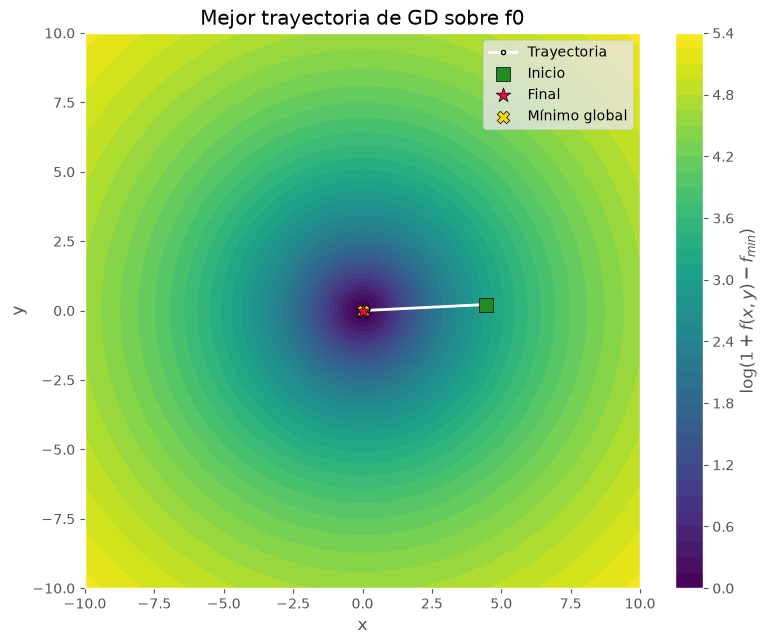

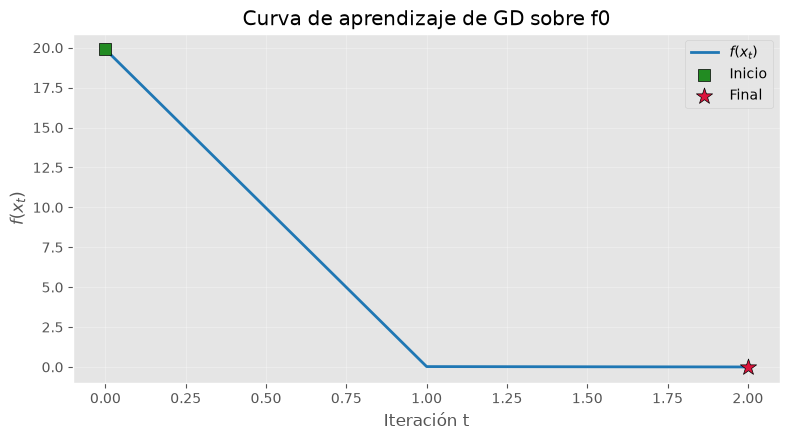

RMSProp sobre f0, corrida 7: convergió en 2 iteraciones; f=0.000044.


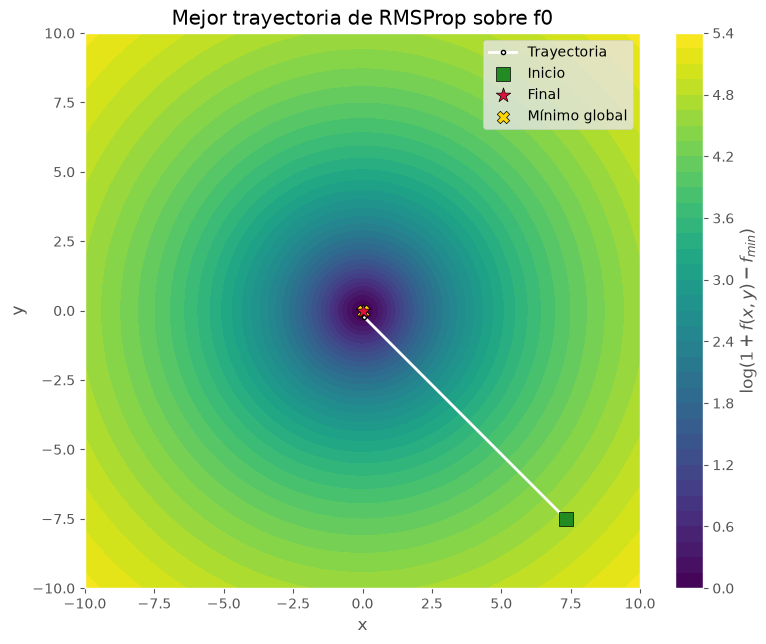

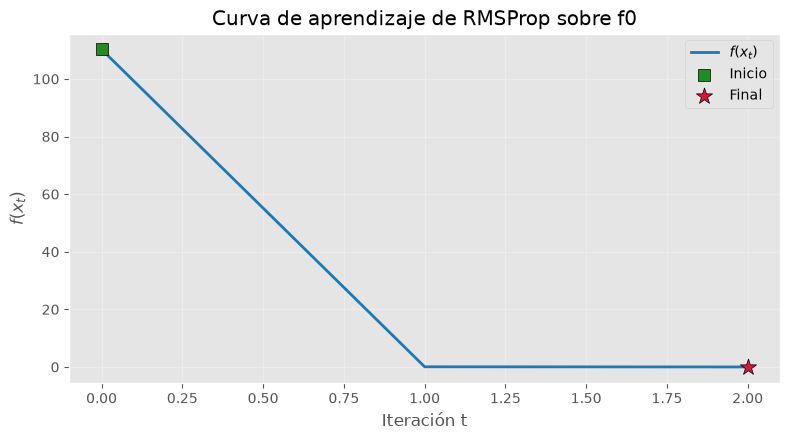

In [40]:
utils.graficar_mejor_corrida(
    "GD",
    "f0",
    **contexto_graficas_evaluacion,
)
utils.graficar_mejor_corrida(
    "RMSProp",
    "f0",
    **contexto_graficas_evaluacion,
)

GD sobre f1, corrida 1: no hubo convergencia; se muestra el menor valor final disponible; f=2.588320.


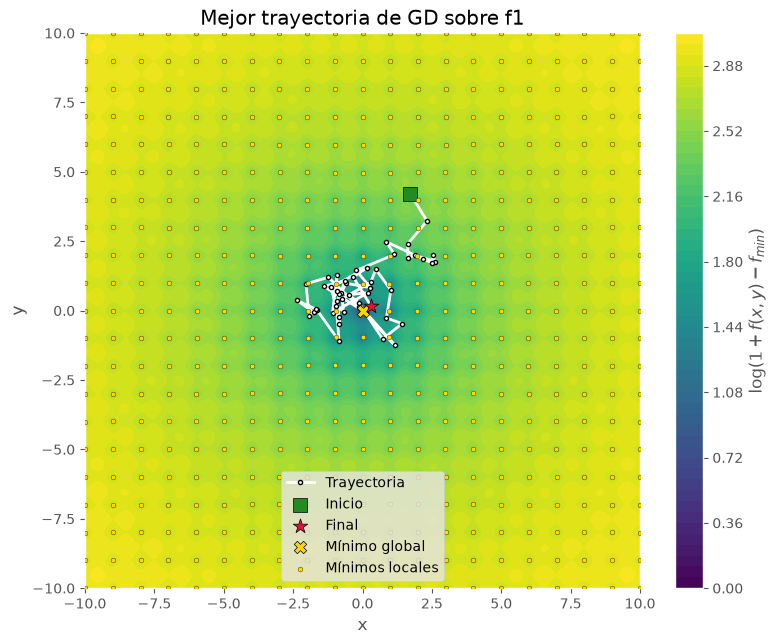

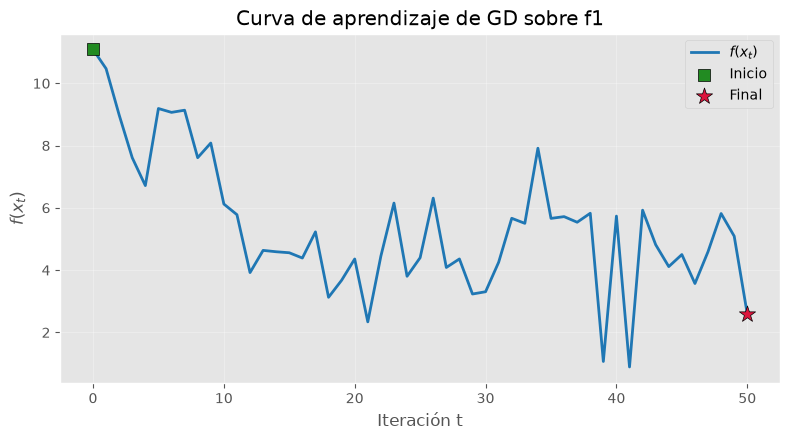

RMSProp sobre f1, corrida 5: no hubo convergencia; se muestra el menor valor final disponible; f=8.616490.


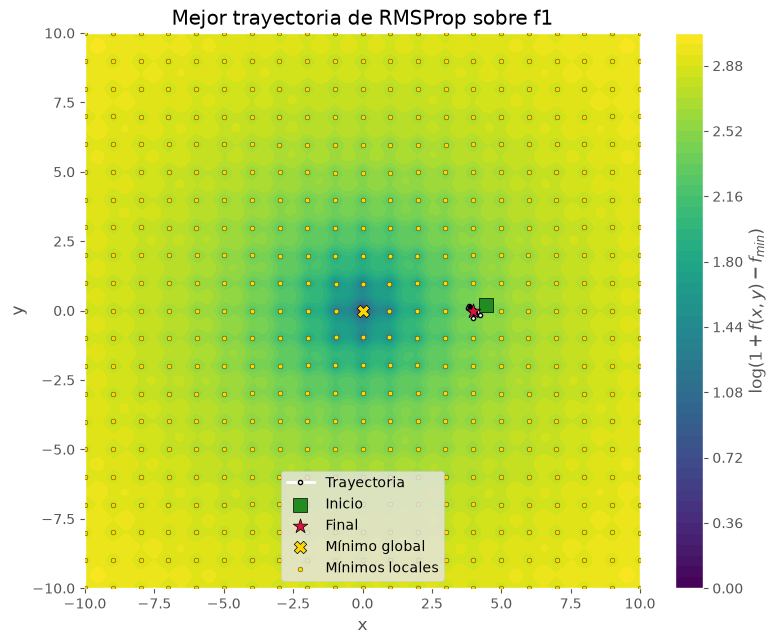

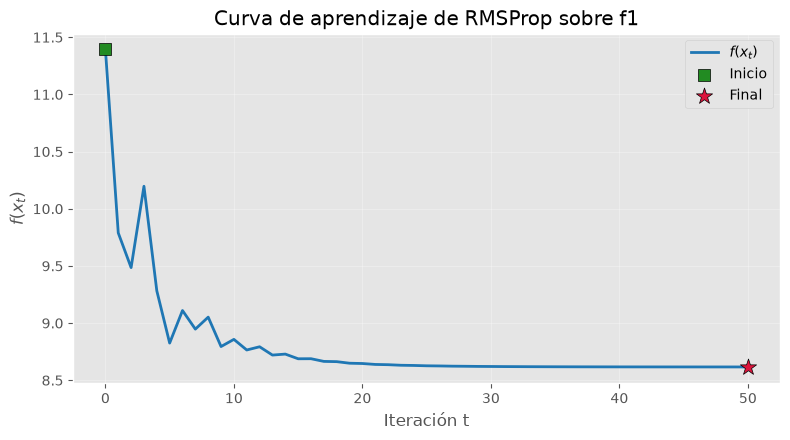

In [41]:
utils.graficar_mejor_corrida(
    "GD",
    "f1",
    **contexto_graficas_evaluacion,
)
utils.graficar_mejor_corrida(
    "RMSProp",
    "f1",
    **contexto_graficas_evaluacion,
)

GD sobre f2, corrida 3: convergió en 14 iteraciones; f=0.000433.


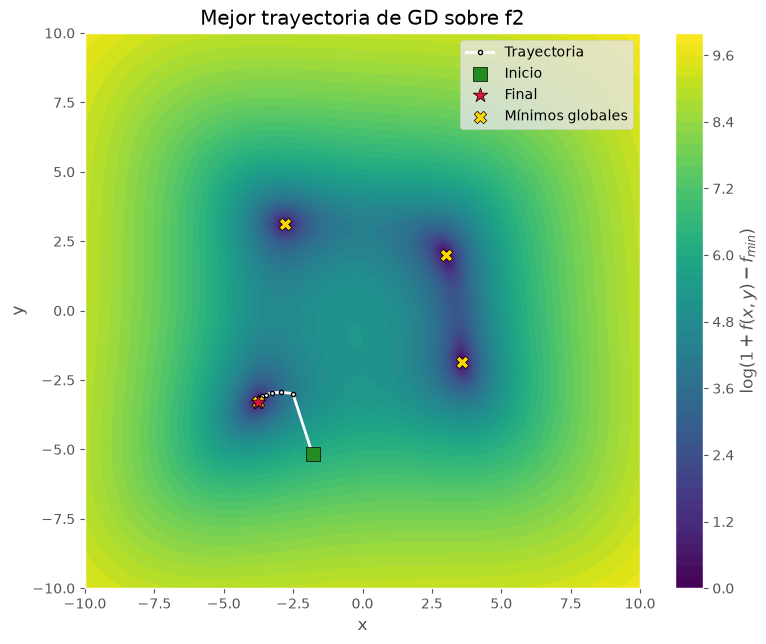

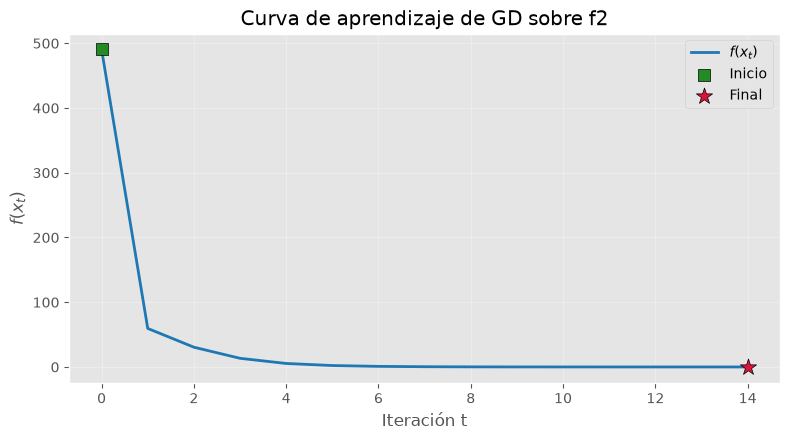

RMSProp sobre f2, corrida 5: convergió en 7 iteraciones; f=0.000829.


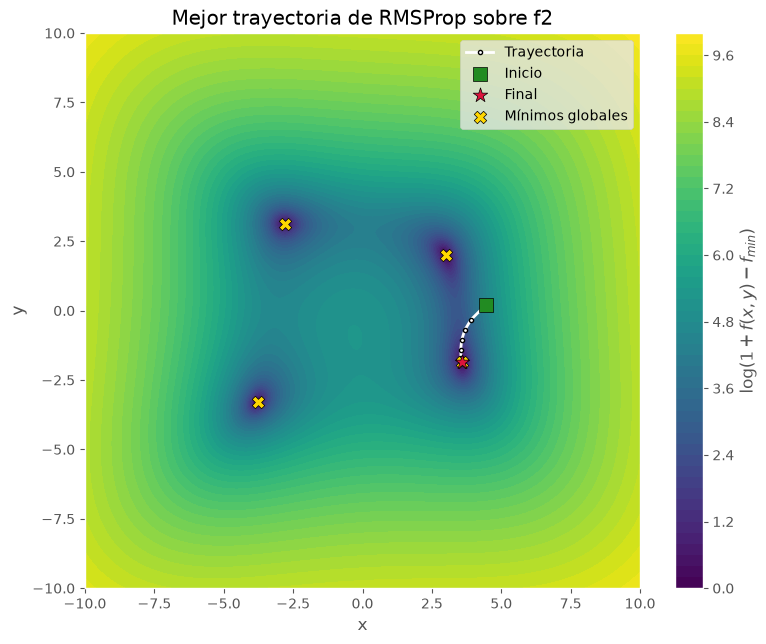

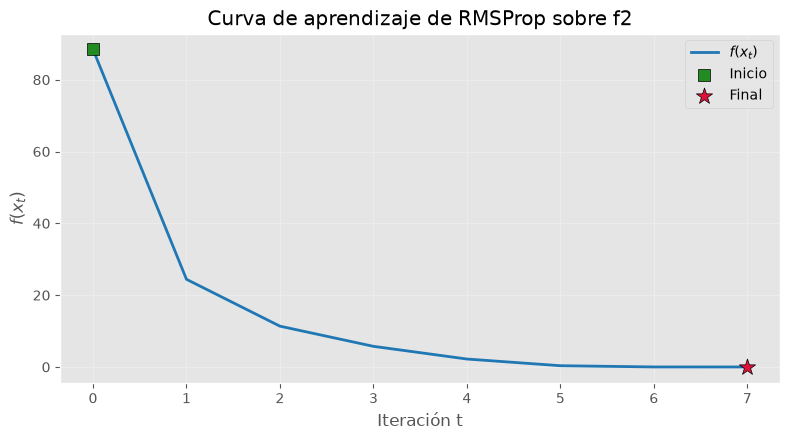

In [42]:
utils.graficar_mejor_corrida(
    "GD",
    "f2",
    **contexto_graficas_evaluacion,
)
utils.graficar_mejor_corrida(
    "RMSProp",
    "f2",
    **contexto_graficas_evaluacion,
)

## Comparación, conclusiones y referencias

- TODO: Comparar los métodos a partir de resultados reproducibles.
- TODO: Responder las preguntas conceptuales y citar fuentes externas.
- TODO: Registrar limitaciones y conclusiones.
